![logo](../../../logoline_c3s.svg)

# Satellite soil moisture for drought monitoring in Europe (2023 case study)

Production date: 03-04-2026

Produced by: Amaya Camila Trigoso Barrientos (VUB)

## 🌍 Use case: Supporting monitoring of drought conditions across Europe during the growing season to inform agricultural risk management and climate impact assessments.

## ❓ Quality assessment question(s)
**Is satellite-derived soil moisture data sufficiently complete, consistent, and temporally representative to reliably detect and monitor anomalies in drought conditions at continental and regional scales?**

This assessment evaluates the suitability of satellite-derived soil moisture data for drought monitoring in Europe, with a specific focus on data completeness in the context of anomaly-based analysis. Completeness is assessed in terms of the availability of valid observations required to construct a 30-year climatological baseline (1991–2020) and to support dekadal (10-day) anomaly calculations. The analysis does not aim to provide a comprehensive evaluation of all quality dimensions, but rather to examine whether the dataset provides sufficient temporal and spatial support for this specific use case. In this context, completeness is considered a critical factor influencing the reliability of standardized soil moisture anomalies (SSMA), particularly given the uneven temporal distribution of observations across the record. The objective of this assessment is to determine to what extent the dataset provides adequate baseline support to reliably detect and monitor drought conditions at continental and regional scales, using the 2023 European drought as a case study.

## 📢 Quality assessment statement

```{admonition} These are the key outcomes of this assessment
:class: note
* The dataset provides adequate spatial and temporal consistency to capture the main large-scale drought patterns across Europe during the 2023 growing season.
* Data completeness varies significantly across regions and seasons, with lower availability in areas affected by snow cover, complex terrain, and dense vegetation.
* Applying stricter baseline completeness thresholds improves the reliability of anomaly estimates but reduces spatial coverage, particularly in regions with historically sparse observations.
* The dataset is suitable for qualitative drought monitoring and regional-scale analysis, but limitations in baseline representativeness and surface sensitivity should be considered for quantitative applications.

```

## 📋 Methodology

The C3S COMBINED satellite soil moisture dataset was downloaded for the period 1991–2023 and spatially subsetted to Europe. The analysis focuses on the volumetric surface soil moisture variable aggregated at dekadal (10-day) resolution. A land mask based on European boundaries was applied to exclude ocean pixels from all analyses.

To assess the suitability of the dataset for anomaly-based drought monitoring, completeness was evaluated in terms of the availability of valid observations required to construct a 30-year climatological baseline (1991–2020). The number of valid years per pixel and dekad was quantified, and different completeness thresholds were applied (no threshold, ≥50%, ≥70%) to evaluate their impact on anomaly calculations.

SSMA for 2023 were computed at the dekadal scale using the baseline mean and standard deviation for each pixel and day-of-year. The analysis focuses on the March–August period to capture the onset, development, and peak of the 2023 European drought.

Spatial maps were generated for selected dekads to compare anomaly patterns under different completeness thresholds, and predefined regions were used to analyse regional behaviour. For each region, the distribution of SSMA across land pixels was summarized using the median and interquartile range (IQR), and data completeness was quantified as the percentage of valid pixels contributing to each dekad.

The methodology is designed to evaluate how data availability influences the reliability of anomaly-based drought indicators, rather than to provide a full validation against reference datasets.

**[](satellite_satellite-soil-moisture_completeness_q02:section-1)**
 * Import packages
 * Define dataset request and parameters
 * Download and transform soil moisture data
 * Spatially subset to Europe
 * Apply land mask to exclude ocean pixels

**[](satellite_satellite-soil-moisture_completeness_q02:section-2)**
 * Compute number of valid years per pixel and dekad (1991–2020)
 * Visualize spatial distribution of baseline support
 * Analyse completeness patterns across regions and seasons
 * Identify areas with limited baseline representativeness

**[](satellite_satellite-soil-moisture_completeness_q02:section-3)**
 * Evaluate completeness across years and dekads (1991–2023)
 * Analyse seasonal and interannual variability in data availability
 * Relate completeness patterns to known limitations
   
**[](satellite_satellite-soil-moisture_completeness_q02:section-4)**
 * Compute climatological mean and standard deviation per dekad
 * Apply completeness thresholds (no threshold, ≥50%, ≥70%)
 * Calculate standardized soil moisture anomalies (SSMA) for 2023
 * Mask pixels not meeting threshold criteria

**[](satellite_satellite-soil-moisture_completeness_q02:section-5)**
 * Generate maps of SSMA for selected dekads (April–July 3rd dekads)
 * Compare spatial patterns across thresholds
 * Relate patterns to drought evolution reported in literature
   
**[](satellite_satellite-soil-moisture_completeness_q02:section-6)**
 * Define regions of interest
 * Compute median SSMA and IQR over land pixels
 * Quantify completeness (% valid pixels) per dekad
 * Compare temporal evolution across thresholds
 * Interpret results in the context of drought development

## 📈 Analysis and results

(satellite_satellite-soil-moisture_completeness_q02:section-1)=
### 1. Request and download data

#### Import packages

In [3]:
import xarray as xr
import numpy as np
import fsspec
import os
import geopandas
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D 
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import shapely.geometry
from shapely.geometry import Point
from shapely.geometry import MultiPolygon
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from c3s_eqc_automatic_quality_control import download
from matplotlib import animation, pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib import path
import matplotlib.dates as mdates
import rioxarray as rxr
import requests
import zipfile
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import calendar
from IPython.display import HTML, display
from matplotlib.animation import FuncAnimation, PillowWriter

plt.style.use("seaborn-v0_8-notebook")

#### Set the data request

In [6]:
collection_id = "satellite-soil-moisture"
request = {
    "variable": ["volumetric_surface_soil_moisture"],
    "type_of_sensor": ["combined_passive_and_active"],
    "time_aggregation": ["10_day_average"],
    "year": [
        "1991", "1992", "1993",
        "1994", "1995", "1996",
        "1997", "1998", "1999",
        "2000", "2001", "2002",
        "2003", "2004", "2005",
        "2006", "2007", "2008",
        "2009", "2010", "2011",
        "2012", "2013", "2014",
        "2015", "2016", "2017",
        "2018", "2019", "2020",
        "2023"
    ],
    "month": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12"
    ],
    "day": ["01", "11", "21"],
    "type_of_record": ["cdr"],
    "version": ["v202312"]
}

#### Download data

Administrative boundaries were obtained from the Eurostat GISCO database, ensuring consistency with official European statistical geographies [[1]](https://ec.europa.eu/eurostat/web/gisco/geodata/administrative-units).

In [7]:
# Dataset
ds = download.download_and_transform(
    collection_id,
    request,
    chunks={"year": 1},
    transform_chunks=False,
)

shapefile_url = "https://gisco-services.ec.europa.eu/distribution/v2/countries/shp/CNTR_RG_01M_2024_4326.shp.zip"

# Shapefile
with fsspec.open(f"simplecache::{shapefile_url}") as file:
    world_shape = geopandas.read_file(file)

100%|██████████| 31/31 [00:07<00:00,  4.30it/s]


#### Spatially subset to Europe

In [8]:
#Select soil mouisture variable
da=ds["sm"]

In [9]:
# Filter the shapefile to keep only Europe
europe_shape = world_shape[world_shape["CNTR_ID"].isin([
    # EU + nearby Europe (adjust if needed)
    "AL","AD","AT","BY","BE","BA","BG","CH","CY","CZ","DE","DK","EE","ES","FI",
    "FR","GB","GR","HR","HU","IE","IS","IT","LI","LT","LU","LV","MC","MD","ME",
    "MK","MT","NL","NO","PL","PT","RO","RS","SE","SI","SK","SM","UA","VA","XK","UK"
])]
# Ensure soil_moisture has CRS information compatible with europe_shape (e.g., EPSG:4326)
da.rio.write_crs("EPSG:4326", inplace=True)
# Clip soil moisture data to the Europe shape
da_eu = da.rio.clip(europe_shape.geometry, europe_shape.crs, drop=True)

(satellite_satellite-soil-moisture_completeness_q02:section-2)=
### 2. Baseline completeness assessment

To assess whether the dataset provides sufficient baseline support for computing standardized soil moisture anomalies (SSMA), the number of valid years available for each pixel and dekad was quantified over the 1991–2020 reference period, which corresponds to the standard 30-year climatological baseline recommended by the World Meteorological Organization (WMO)[[2]](https://community.wmo.int/site/knowledge-hub/programmes-and-initiatives/climate-services/wmo-climatological-normals). The most recent years (2021–2022) were not included to ensure consistency with established climatological reference periods and to avoid mixing the baseline with the period of analysis. In addition, recent years—particularly 2022—were characterized by pronounced drought conditions in Europe [[3]](https://doi.org/10.2760/998985); including such anomalous years in the baseline could bias the climatological mean and standard deviation, thereby reducing the sensitivity of the anomaly calculation.

The soil moisture time series was first subset to the baseline period and grouped by dekad of the year (36 dekads per year). For each dekad and pixel, the number of years containing a valid soil moisture value was counted. This results in a spatially explicit estimate of baseline sample size, ranging from 0 to 30 years, which represents the number of observations available to compute the climatological mean and standard deviation for that dekad. The resulting maps show the distribution of baseline support across selected dekads of the year. 

This analysis is performed to evaluate whether the available baseline data are sufficient to support robust anomaly calculations. Although the dataset is provided as dekadal aggregates, the effective sample size underlying the climatology can vary substantially across space and time. In some regions and dekads, only a limited number of valid years are available, which may reduce the reliability of the derived anomalies. Therefore, assessing baseline support is a useful step to interpret the SSMA results within the scope of this drought monitoring use case.

This assessment focuses on the availability of valid dekadal values across years, rather than the number of daily observations contributing to each dekadal aggregate, as the anomaly calculation depends primarily on the robustness of the baseline climatology.

In [10]:
# Keep only the baseline period
da_baseline = da_eu.sel(time=slice("1991-01-01", "2020-12-31"))

# Build a dekad-of-year index from the timestamp
# Dekads:
# day 1  -> dekad 1 of month
# day 11 -> dekad 2 of month
# day 21 -> dekad 3 of month
# Then combine months into 1..36 across the year
month = da_baseline["time"].dt.month
day = da_baseline["time"].dt.day

dekad_in_month = xr.where(day <= 10, 1,
                  xr.where(day <= 20, 2, 3))

dekad_of_year = (month - 1) * 3 + dekad_in_month
dekad_of_year.name = "dekad_of_year"

# Attach year and dekad_of_year as coordinates
da_baseline = da_baseline.assign_coords(
    year=("time", da_baseline["time"].dt.year.data),
    dekad_of_year=("time", dekad_of_year.data)
)

# Count valid observations across years for each dekad-of-year and pixel
# Result dims: dekad_of_year, latitude, longitude
baseline_valid_years = da_baseline.notnull().groupby("dekad_of_year").sum(dim="time")

# Ensure integer type for plotting / storage
baseline_valid_years = baseline_valid_years.astype(np.int16)

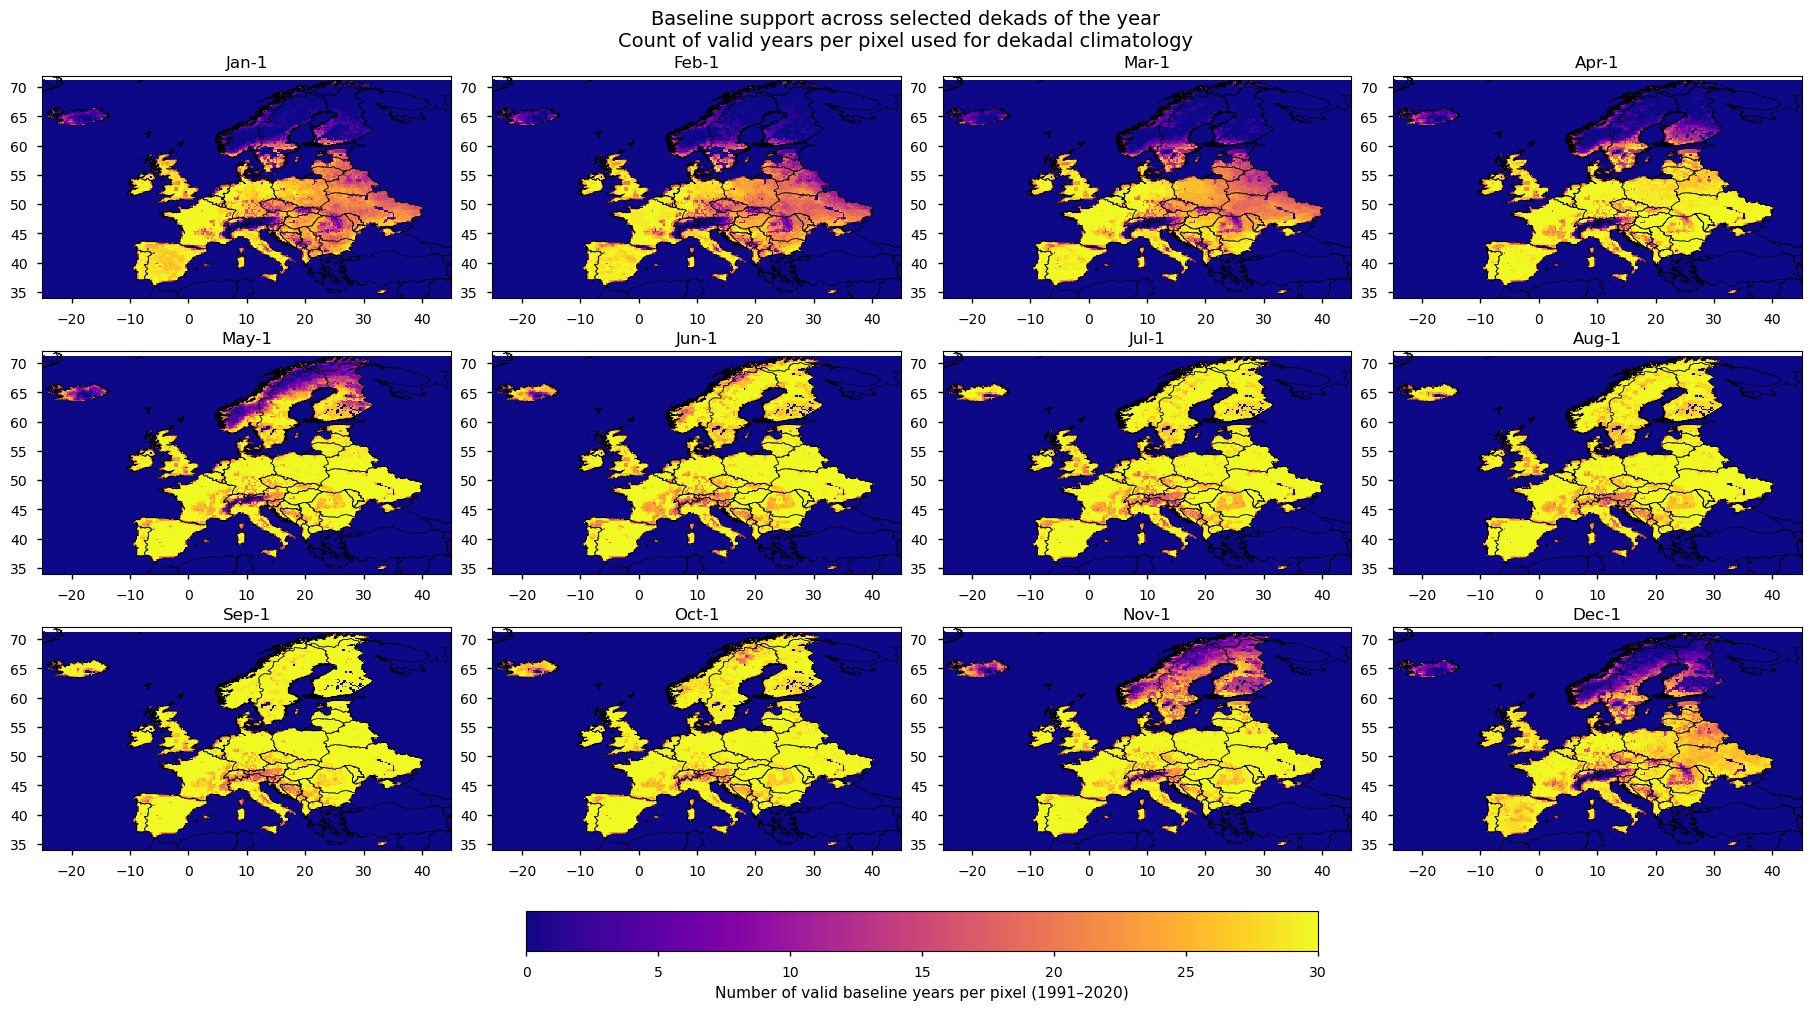

In [11]:
# Representative dekads through the year
selected_dekads = [1, 4, 7, 10, 13, 16, 19, 22, 25, 28, 31, 34]

# Optional labels
dekad_labels = {
    1:  "Jan-1",
    4:  "Feb-1",
    7:  "Mar-1",
    10: "Apr-1",
    13: "May-1",
    16: "Jun-1",
    19: "Jul-1",
    22: "Aug-1",
    25: "Sep-1",
    28: "Oct-1",
    31: "Nov-1",
    34: "Dec-1",
}

fig, axes = plt.subplots(3, 4, figsize=(18, 10), constrained_layout=True)

for ax, d in zip(axes.flat, selected_dekads):
    da_plot = baseline_valid_years.sel(dekad_of_year=d)

    im = da_plot.plot(
        ax=ax,
        x="longitude",
        y="latitude",
        vmin=0,
        vmax=30,
        cmap="plasma",
        add_colorbar=False
    )

    # Optional: overlay borders if world_shape already exists
    try:
        world_shape.boundary.plot(ax=ax, linewidth=0.4, color="black")
    except Exception:
        pass

    # Europe-focused extent; adjust if needed
    ax.set_xlim(-25, 45)
    ax.set_ylim(34, 72)

    ax.set_title(f"{dekad_labels.get(d, f'Dekad {d}')}")
    ax.set_xlabel("")
    ax.set_ylabel("")

# Hide any unused axes
for ax in axes.flat[len(selected_dekads):]:
    ax.set_visible(False)

cbar = fig.colorbar(im, ax=axes, orientation="horizontal", fraction=0.05, pad=0.04)
cbar.set_label("Number of valid baseline years per pixel (1991–2020)")

fig.suptitle(
    "Baseline support across selected dekads of the year\n"
    "Count of valid years per pixel used for dekadal climatology",
    fontsize=14
)

plt.show()

*Figure 1. Number of valid baseline years per pixel (1991–2020) for selected dekads of the year.*

(satellite_satellite-soil-moisture_completeness_q02:section-3)=
### 3. Temporal completeness analysis

Completeness was calculated for each year–dekad combination between 1991 and 2023 as the percentage of valid land pixels within the study domain. A land mask derived from the European land geometry was applied so that only inland pixels were included. The resulting heatmap shows how data availability changes through both the seasonal cycle and the observational record, and helps identify whether low completeness is concentrated in specific years or dekads.

In [12]:
def plot_year_dekad_completeness_heatmap(
    da_eu: xr.DataArray,
    europe_shape,
    start_year=1991,
    end_year=2023,
    title=None,
):
    """
    Plot a heatmap of completeness (% valid land pixels) by year and dekad of year.
    """

    da_sel = da_eu.sel(time=slice(f"{start_year}-01-01", f"{end_year}-12-31"))

    # Land mask from first timestep
    dummy = xr.full_like(da_sel.isel(time=0), fill_value=1)
    dummy = dummy.rio.write_crs("EPSG:4326")

    clipped = dummy.rio.clip(europe_shape.geometry, europe_shape.crs, drop=False)
    land_mask = clipped.notnull()

    total_land_pixels = int(land_mask.sum().compute().item())
    if total_land_pixels == 0:
        raise ValueError("No land pixels found in the selected domain.")

    # Keep only land pixels
    da_land = da_sel.where(land_mask)

    years = np.arange(start_year, end_year + 1)
    dekads = np.arange(1, 37)

    completeness = np.full((len(years), len(dekads)), np.nan)

    for i, year in enumerate(years):
        for j, dekad in enumerate(dekads):
            # Convert dekad number (1..36) to month and dekad-in-month
            month = (dekad - 1) // 3 + 1
            dekad_in_month = (dekad - 1) % 3 + 1

            if dekad_in_month == 1:
                day_cond = da_land.time.dt.day <= 10
            elif dekad_in_month == 2:
                day_cond = (da_land.time.dt.day >= 11) & (da_land.time.dt.day <= 20)
            else:
                day_cond = da_land.time.dt.day >= 21

            time_mask = (
                (da_land.time.dt.year == year) &
                (da_land.time.dt.month == month) &
                day_cond
            )

            da_sub = da_land.sel(time=time_mask)

            if da_sub.sizes.get("time", 0) == 0:
                continue

            valid_pixels = da_sub.notnull().sum(dim=["time", "latitude", "longitude"]).compute().item()
            possible_pixels = da_sub.sizes["time"] * total_land_pixels

            completeness[i, j] = valid_pixels / possible_pixels * 100 if possible_pixels > 0 else np.nan

    plt.figure(figsize=(14, 6), dpi=250)
    im = plt.imshow(
        completeness,
        aspect="auto",
        origin="lower",
        vmin=0,
        vmax=100,
    )

    plt.colorbar(im, label="Valid land pixels (%)")
    plt.xlabel("Dekad of year")
    plt.ylabel("Year")

    plt.xticks(
        ticks=[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33],
        labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
    )
    plt.yticks(
        ticks=np.arange(0, len(years), 2),
        labels=years[::2]
    )

    if title is None:
        title = "Completeness over land pixels by year and dekad"
    plt.title(title)
    plt.tight_layout()
    plt.show()

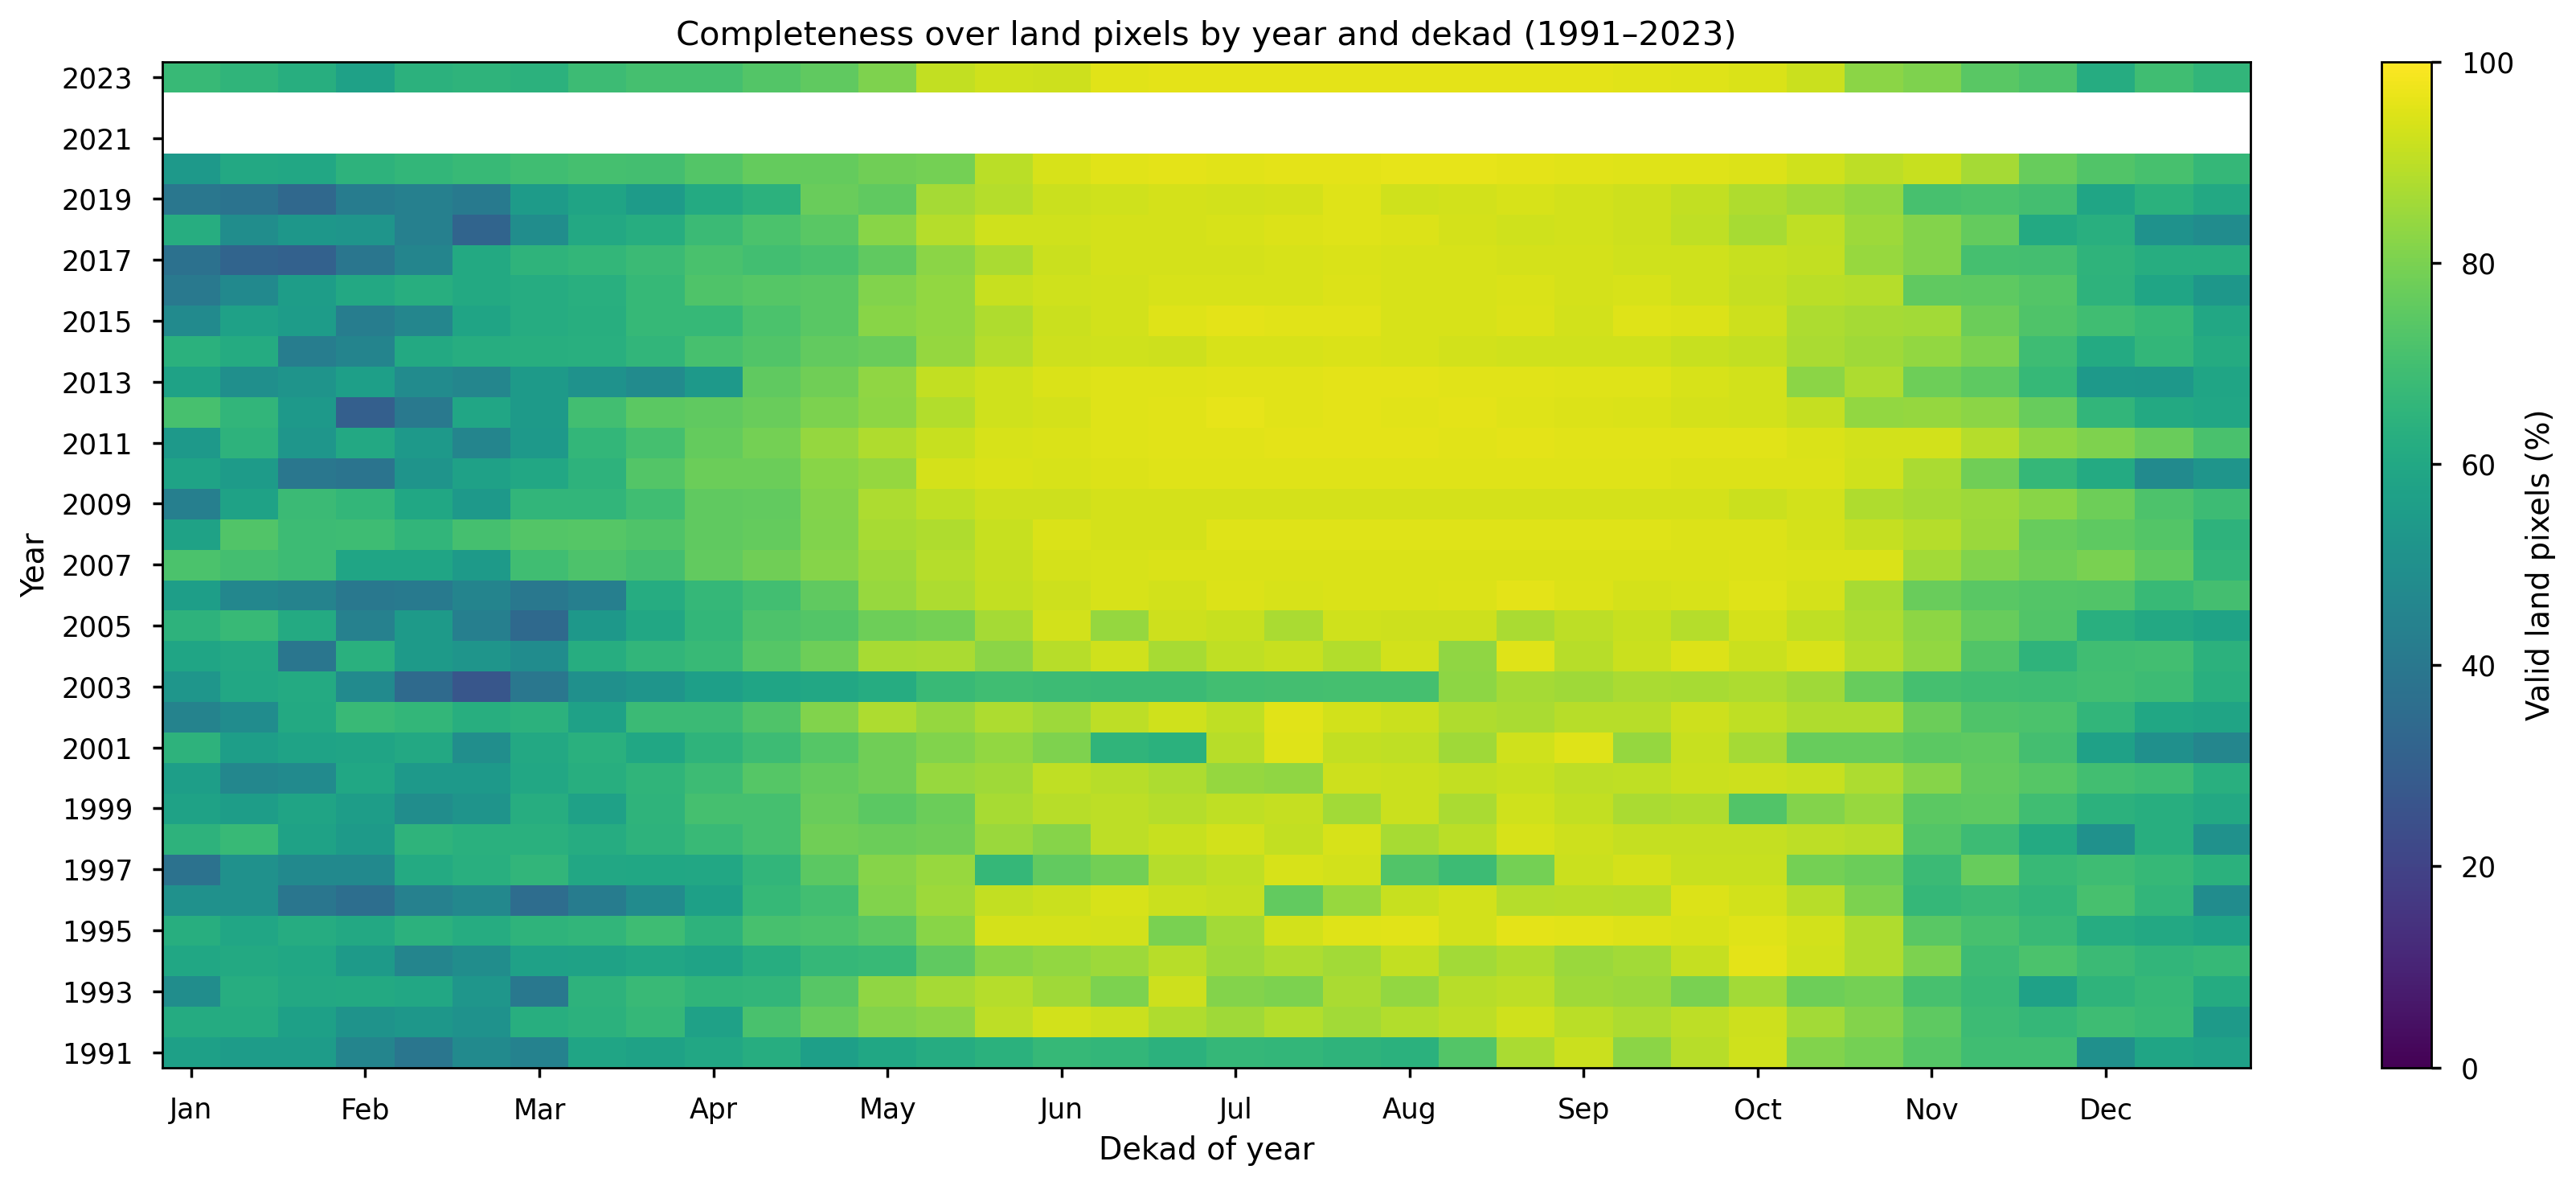

In [13]:
plot_year_dekad_completeness_heatmap(
    da_eu=da_eu,
    europe_shape=europe_shape,
    start_year=1991,
    end_year=2023,
    title="Completeness over land pixels by year and dekad (1991–2023)"
)

*Figure 2. Heatmap of completeness over European land pixels by year and dekad (1991–2023), expressed as the percentage of valid observations.*

The results presented in Figures 1 and 2 are consistent with the spatial and temporal completeness assessment described in the Product Quality Assessment Report [(PQAR)](https://confluence.ecmwf.int/pages/viewpage.action?pageId=445290728). 

Figure 1 shows that completeness is lower in regions affected by seasonal soil moisture freeze–thaw processes, particularly at higher latitudes and during the winter season. Reduced completeness is also observed in mountainous areas, as well as in some urban regions (e.g. around London), which may be influenced by radio-frequency interference (RFI).

Figure 2 indicates a clear seasonal signal, with generally higher completeness across Europe (approximately between 35°N and 70°N) during the May–September period. It can also be observed that completeness during the spring–summer months is lower in earlier years of the record, particularly prior to 2007. This is consistent with Figure 4 of the PQAR, which highlights that the addition of AMSR-E (from 2002) and ASCAT (from 2007) significantly improved spatial coverage. This improvement is reflected in Figure 2, where a noticeable increase in completeness is observed following the introduction of ASCAT in 2007.

(satellite_satellite-soil-moisture_completeness_q02:section-4)=
### 4. SSMA computation under different thresholds

The SSMA was calculated following a similar approach as the one explained by the European Drought Observatory (EDO) [[4]](https://drought.emergency.copernicus.eu/data/factsheets/factsheet_soilmoisture.pdf). Surface soil moisture values for each pixel and each dekad of the year 2023 were compared to the long-term climatological period (1991–2020, 30 years). The anomaly was computed using the following equation:

$\text{SMA} = \frac{\text{SMI}_t - \overline{\text{SMI}}}{\delta_{\text{SMI}}}$

where:

$\text{SMI}_t$ = Surface soil moisture 2023 for a specific dekad for that pixel

$\overline{\text{SMI}}$ = Mean surface soil moisture 1991-2020 for that same dekad for that pixel

$\delta_{\text{SMI}}$ = Standard deviation surface soil moisture 1991-2020 for that same dekad for that pixel

Furthermore, based on the completeness analysis presented in the previous section, a minimum baseline-availability threshold was introduced in the SSMA calculation. For each pixel and each dekad, the number of years within the 1991–2020 baseline period containing a valid soil moisture value was counted. A threshold was then applied requiring that a minimum fraction of these 30 years be available in order to compute the climatological mean and standard deviation.

Specifically, thresholds of 50% and 70% were tested, corresponding to at least 15 and 21 valid years, respectively, for a given pixel–dekad combination. If the number of valid years did not meet the selected threshold, the anomaly for that pixel and dekad was masked and not included in the analysis. A no-threshold case was also retained for comparison, where anomalies are computed regardless of baseline availability.

The threshold is applied at the dekadal level across years and does not account for the number of daily observations contributing to each dekadal aggregate. This is consistent with common practice in drought monitoring applications, where anomalies are typically computed from dekadal products, as also adopted in Joint Research Centre (JRC) Global Drought Observatory (GDO) analyses [[3]](https://doi.org/10.2760/998985) [[5]](https://doi.org/10.2760/575433) [[6]](https://doi.org/10.2760/928418). Given the focus of this use case on dekadal-scale drought conditions, this approach was considered appropriate.

In [14]:
def compute_ssma_with_threshold(
    da_eu,
    baseline_start="1991-01-01",
    baseline_end="2020-12-21",
    target_start="2023-01-01",
    target_end="2023-12-21",
    threshold=0.7,
):
    """
    Compute standardized soil moisture anomalies (SSMA) with an optional
    baseline completeness threshold.

    Parameters
    ----------
    da_eu : xarray.DataArray
        Dekadal soil moisture data with dimensions (time, latitude, longitude).
    baseline_start, baseline_end : str
        Baseline period.
    target_start, target_end : str
        Target period for anomaly calculation.
    threshold : float or None
        Fraction of baseline years required for each DOY/pixel.
        Example: 0.7 means at least 70% of years must be valid.
        If None, no completeness threshold is applied.

    Returns
    -------
    ssma : xarray.DataArray
        Standardized anomalies for the target period.
    mean_long_term : xarray.DataArray
        Baseline mean by day of year.
    std_long_term_safe : xarray.DataArray
        Baseline std by day of year, with zeros replaced by NaN.
    valid_counts : xarray.DataArray
        Number of valid baseline years per DOY and pixel.
    complete_mask : xarray.DataArray
        Boolean mask showing where the threshold is met.
    min_required_years : int or None
        Minimum number of years required under the selected threshold.
    total_years : int
        Number of years in the baseline period.
    """

    # Select long-term (baseline) and target period
    da_long_term = da_eu.sel(time=slice(baseline_start, baseline_end))
    da_target = da_eu.sel(time=slice(target_start, target_end))

    # Group baseline by day-of-year
    doy_long_term = da_long_term.groupby("time.dayofyear")

    # Count valid (non-NaN) years for each DOY at each pixel
    valid_counts = doy_long_term.count(dim="time")

    # Total number of years in the baseline
    total_years = len(np.unique(da_long_term["time"].dt.year.values))

    # Build completeness mask
    if threshold is None:
        min_required_years = None
        complete_mask = xr.ones_like(valid_counts, dtype=bool)
    else:
        min_required_years = int(np.ceil(threshold * total_years))
        complete_mask = valid_counts >= min_required_years

    # Compute long-term mean and std
    mean_long_term = doy_long_term.mean(dim="time", skipna=True)
    std_long_term = doy_long_term.std(dim="time", skipna=True)

    # Avoid division by zero
    std_long_term_safe = std_long_term.where(std_long_term != 0)

    # Group target year by DOY
    doy_target = da_target.groupby("time.dayofyear")
    sm_target = doy_target.mean(dim="time", skipna=True)

    # Compute standardized anomaly
    ssma_raw = (sm_target - mean_long_term) / std_long_term_safe

    # Apply completeness mask
    ssma = ssma_raw.where(complete_mask)

    # Remove inf values
    ssma = ssma.where(np.isfinite(ssma))

    return ssma, mean_long_term, std_long_term_safe, valid_counts, complete_mask, min_required_years, total_years

In [15]:
ssma_none, mean_lt_none, std_lt_none, valid_counts, mask_none, min_years_none, total_years = compute_ssma_with_threshold(
    da_eu,
    threshold=None
)

ssma_07, mean_lt_07, std_lt_07, valid_counts, mask_07, min_years_07, total_years = compute_ssma_with_threshold(
    da_eu,
    threshold=0.7
)

In [16]:
ssma_05, mean_lt_05, std_lt_05, valid_counts, mask_05, min_years_05, total_years = compute_ssma_with_threshold(
    da_eu,
    threshold=0.5
)

(satellite_satellite-soil-moisture_completeness_q02:section-5)=
### 5. Spatial analysis of anomalies

To support the interpretation of the SSMA results, spatial maps were generated for the third dekad of April, May, June, and July 2023. These four dekads were selected to enable direct comparison with the corresponding multi-panel figure presented in the JRC August 2023 drought report [[6]](https://doi.org/10.2760/928418), which shows the evolution of soil moisture anomaly conditions during late spring and early summer. The standardized anomalies were mapped over Europe using a consistent color scale, and predefined regions of interest were delineated to guide the subsequent regional analysis. The same figure layout was produced for different baseline-availability thresholds in order to visually compare their effect on the spatial patterns of the anomalies.

The comparison with JRC drought products should be interpreted as a qualitative assessment of pattern consistency rather than a strict validation. The C3S COMBINED dataset represents surface soil moisture, while the JRC Soil Moisture Anomaly is derived from LISFLOOD simulations of root-zone soil moisture [[4]](https://drought.emergency.copernicus.eu/data/factsheets/factsheet_soilmoisture.pdf). These differences in depth and methodology imply distinct temporal responses and spatial characteristics, and therefore some discrepancies are expected.

In [19]:
# Define custom colormap and boundaries
colors = [
    "#b35806ff",  # <-2
    "#f1a340ff",  # -2 to -1.5
    "#fee0b6ff",  # -1.5 to -1
    "#ffffffff",  # -1 to 1
    "#d1e5f0ff",  # 1 to 1.5
    "#67a9cfff",  # 1.5 to 2
    "#2166acff"   # >= 2
]
bounds = [-100, -2, -1.5, -1, 1, 1.5, 2, 100]  # Define boundaries

# Create colormap and norm
cmap = mcolors.ListedColormap(colors)
cmap.set_bad(color='lightgray')  # Gray for no data
norm = mcolors.BoundaryNorm(bounds, ncolors=len(colors), clip=True)

In [18]:
boxes = [
    {
        'label': 'Iberian Peninsula', 
        'min_lat': 35, 'max_lat': 44, 
        'min_lon': -10, 'max_lon': 5, 
        'color': 'red'
    },
    {
        'label': 'Great Britain and Ireland', 
        'min_lat': 50, 'max_lat': 60, 
        'min_lon': -11, 'max_lon': 2, 
        'color': 'orange'},

    {
        'label': 'Southern Balkans and Italy',
        'min_lat': 36, 'max_lat': 47,
        'min_lon': 7, 'max_lon': 24,
        'color': 'green'
    },
    {
        'label': 'Nordic and Baltic region',
        'min_lat': 55, 'max_lat': 71,
        'min_lon': 5, 'max_lon': 28,
        'color': 'blue'
    },

    {
        'label': 'Germany–Benelux–Poland',
        'min_lat': 48, 'max_lat': 54,
        'min_lon': 4, 'max_lon': 25,
        'color': 'purple'
    }
]

In [32]:
def plot_ssma_selected_dekads(
    ssma,
    boxes,
    cmap=None,
    norm=None,
    bounds=None,
    main_title="Surface Soil Moisture Anomaly",
    projection=None,
    extent=(-15, 35, 35, 72),
    dpi=250,
):
    """
    Plot SSMA maps for the 3rd dekad of April, May, June, and July 2023
    in a 2x2 panel layout.
    """

    if projection is None:
        projection = ccrs.PlateCarree()

    # Third dekad of April, May, June, July
    selected_months = [4, 5, 6, 7]
    selected_doys = []
    panel_labels = []

    month_names = {
        4: "April",
        5: "May",
        6: "June",
        7: "July"
    }

    for month in selected_months:
        doy = int(
            np.datetime64(f"2023-{month:02d}-21")
            .astype("datetime64[D]")
            .astype(object)
            .timetuple()
            .tm_yday
        )
        selected_doys.append(doy)
        panel_labels.append(f"{month_names[month]} - 3rd Dekad")

    fig, axes = plt.subplots(
        2, 2,
        figsize=(10.5, 8),
        subplot_kw={"projection": projection},
        dpi=dpi
    )

    axes = axes.flatten()

    def add_rectangles(ax):
        for box in boxes:
            width = box["max_lon"] - box["min_lon"]
            height = box["max_lat"] - box["min_lat"]
            rect = Rectangle(
                (box["min_lon"], box["min_lat"]),
                width,
                height,
                linewidth=1,
                edgecolor=box["color"],
                facecolor="none",
                transform=ccrs.PlateCarree(),
                zorder=5
            )
            ax.add_patch(rect)

    im = None

    for ax, doy, label in zip(axes, selected_doys, panel_labels):
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.BORDERS, linestyle="-", edgecolor="black", linewidth=0.6)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
        ax.add_feature(cfeature.LAND, facecolor="lightgray")
        ax.add_feature(cfeature.OCEAN, facecolor="lightgray")

        add_rectangles(ax)

        da_plot = ssma.sel(dayofyear=doy).where(ssma.sel(dayofyear=doy) != 0, np.nan)

        im = da_plot.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            norm=norm,
            add_colorbar=False
        )

        ax.set_title(label, fontsize=10, pad=4)

        # Lat/lon ticks
        gl = ax.gridlines(
            crs=ccrs.PlateCarree(),
            draw_labels=True,
            linewidth=0.3,
            color="gray",
            alpha=0.4,
            linestyle="--"
        )
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 8}
        gl.ylabel_style = {"size": 8}

    ticks = bounds[1:-1] if bounds is not None else None

    # Manual spacing instead of tight_layout
    fig.subplots_adjust(
        left=0.06,
        right=0.94,
        top=0.88,
        bottom=0.14,
        wspace=0.01,
        hspace=0.16
    )

    # Colorbar placed lower
    cbar = fig.colorbar(
        im,
        ax=axes,
        orientation="horizontal",
        fraction=0.045,
        pad=0.08,
        shrink=0.9,
        ticks=ticks,
        extend="both"
    )
    cbar.ax.tick_params(labelsize=8)
    cbar.set_label("SSMA", fontsize=9)

    # Main title + year
    fig.suptitle(f"{main_title} (2023)", fontsize=12, y=0.97)

    return fig

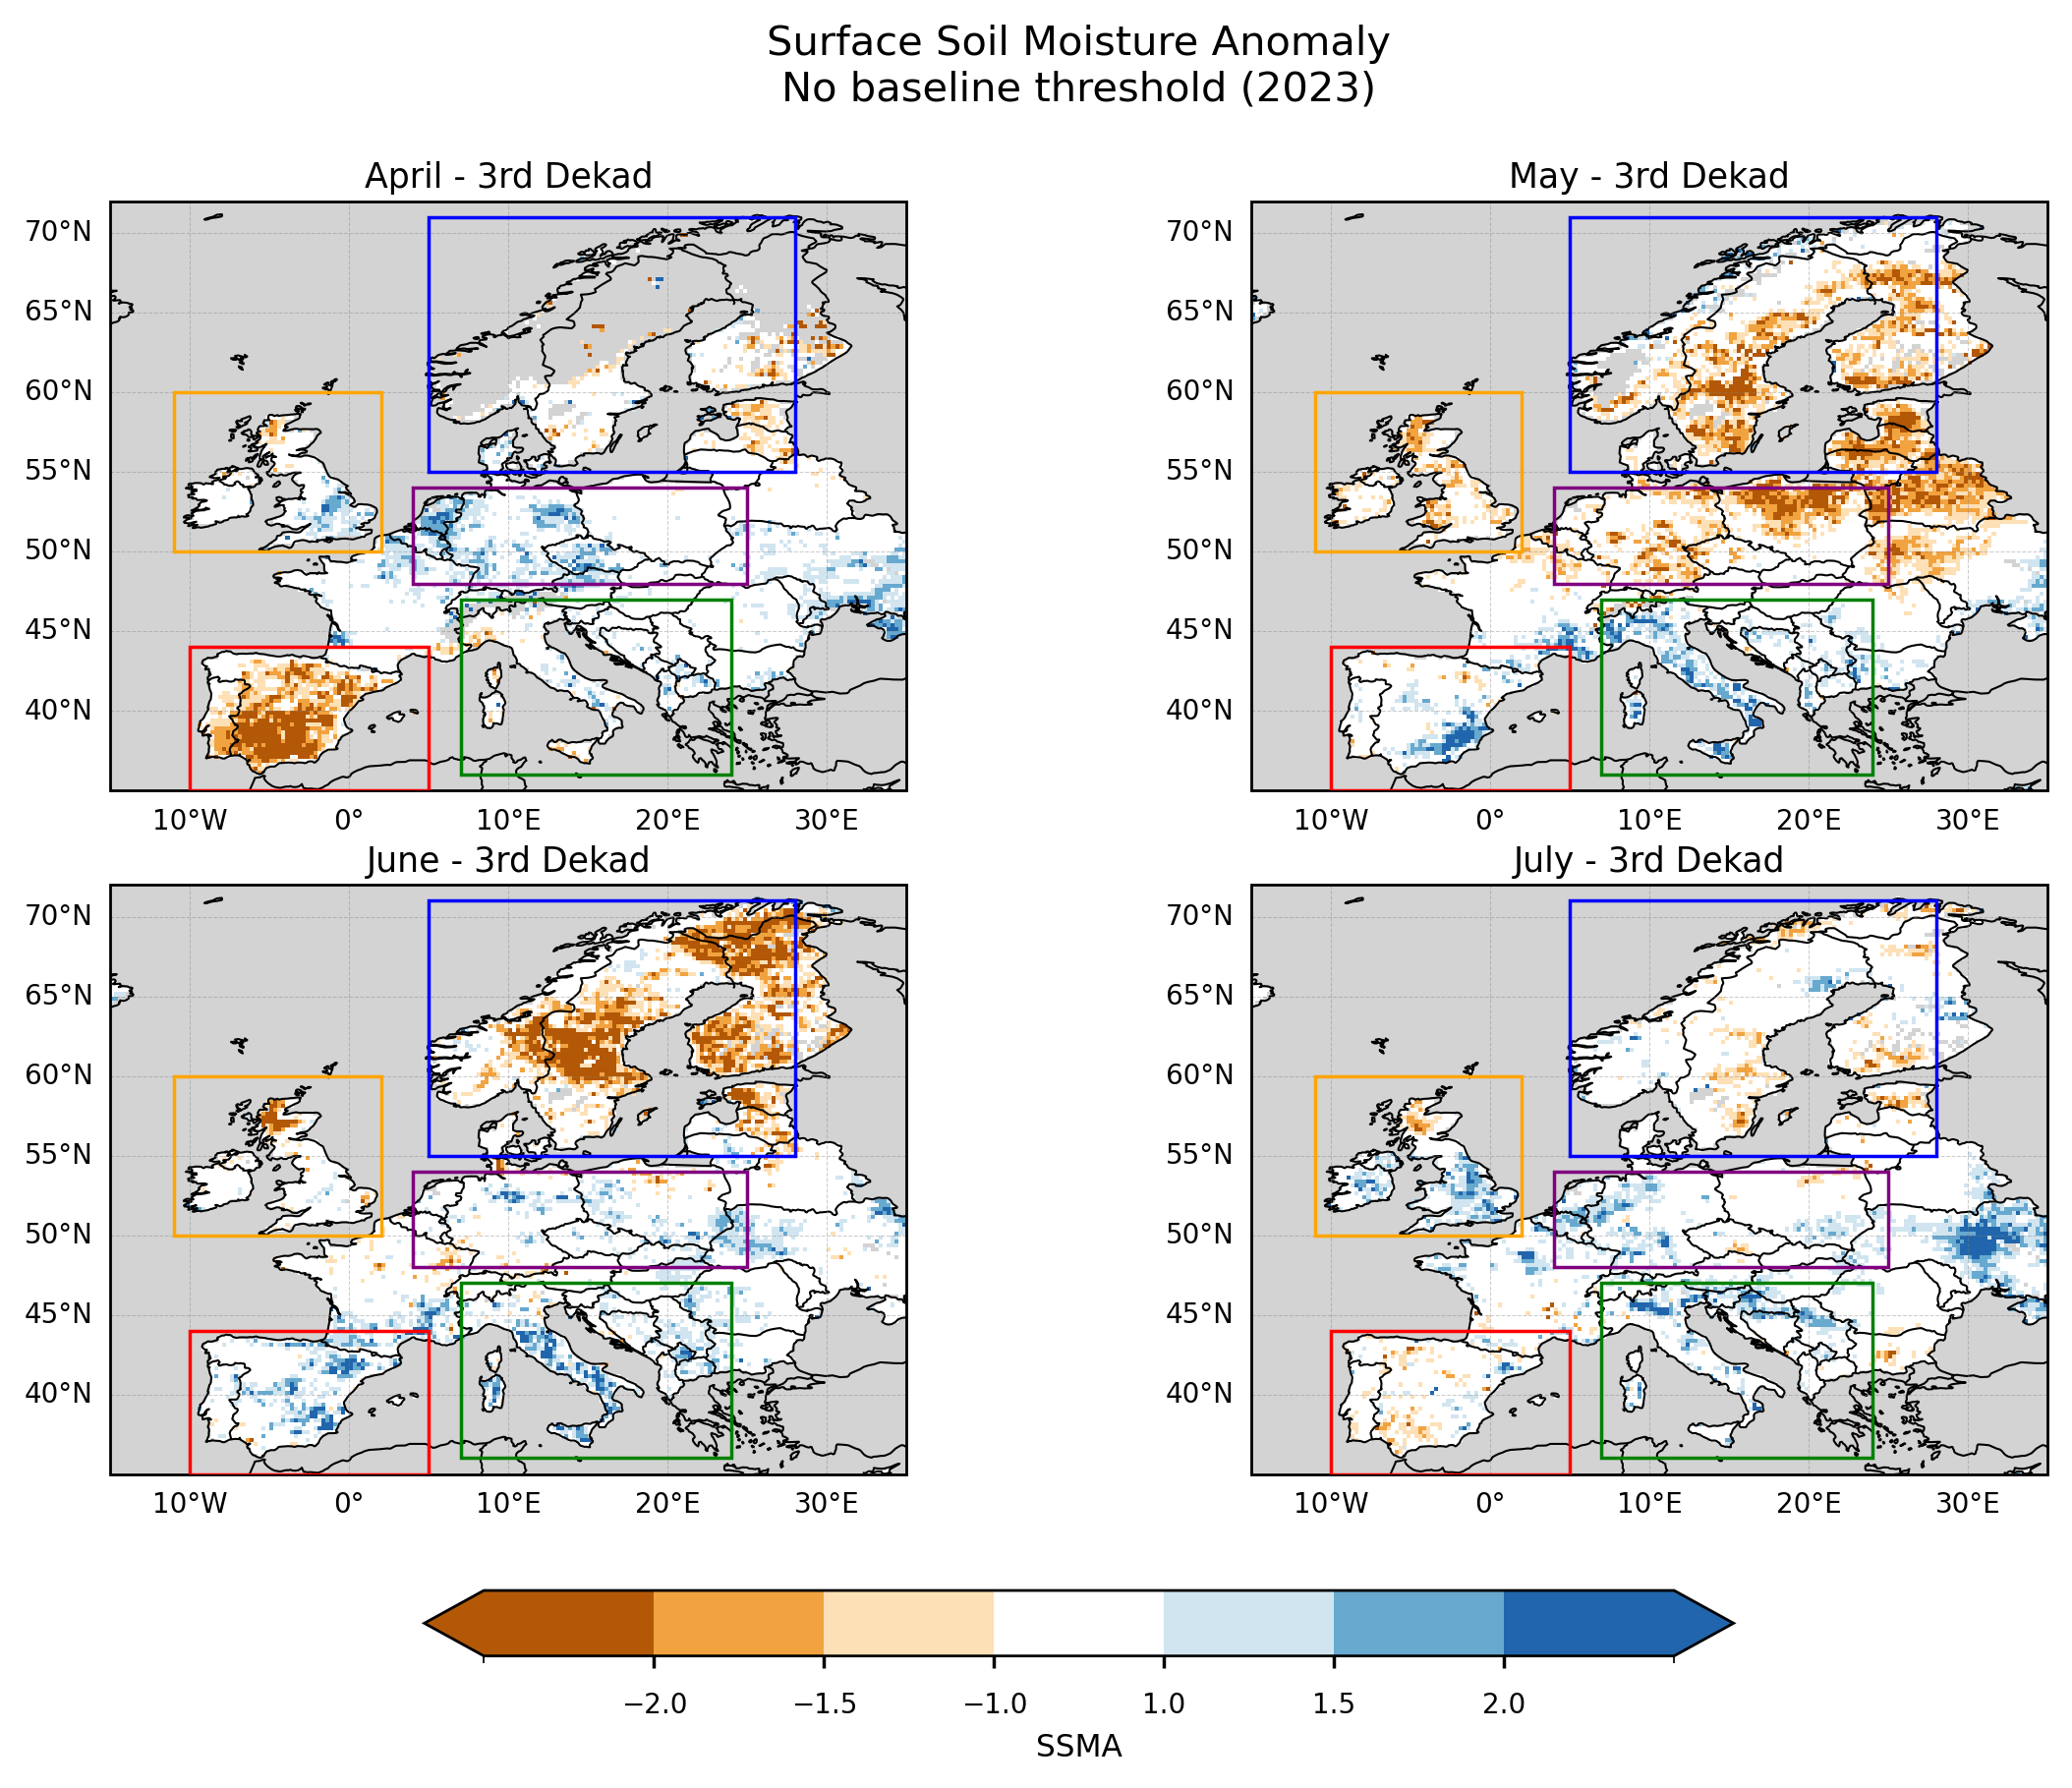

In [33]:
fig_none = plot_ssma_selected_dekads(
    ssma=ssma_none,
    boxes=boxes,
    cmap=cmap,
    norm=norm,
    bounds=bounds,
    main_title="Surface Soil Moisture Anomaly\nNo baseline threshold"
)
plt.show()

*Figure 3. SSMA over Europe for the third dekad of April, May, June, and July 2023. Anomalies are computed without applying a baseline completeness threshold. Boxes indicate the regions selected for subsequent regional analysis.*

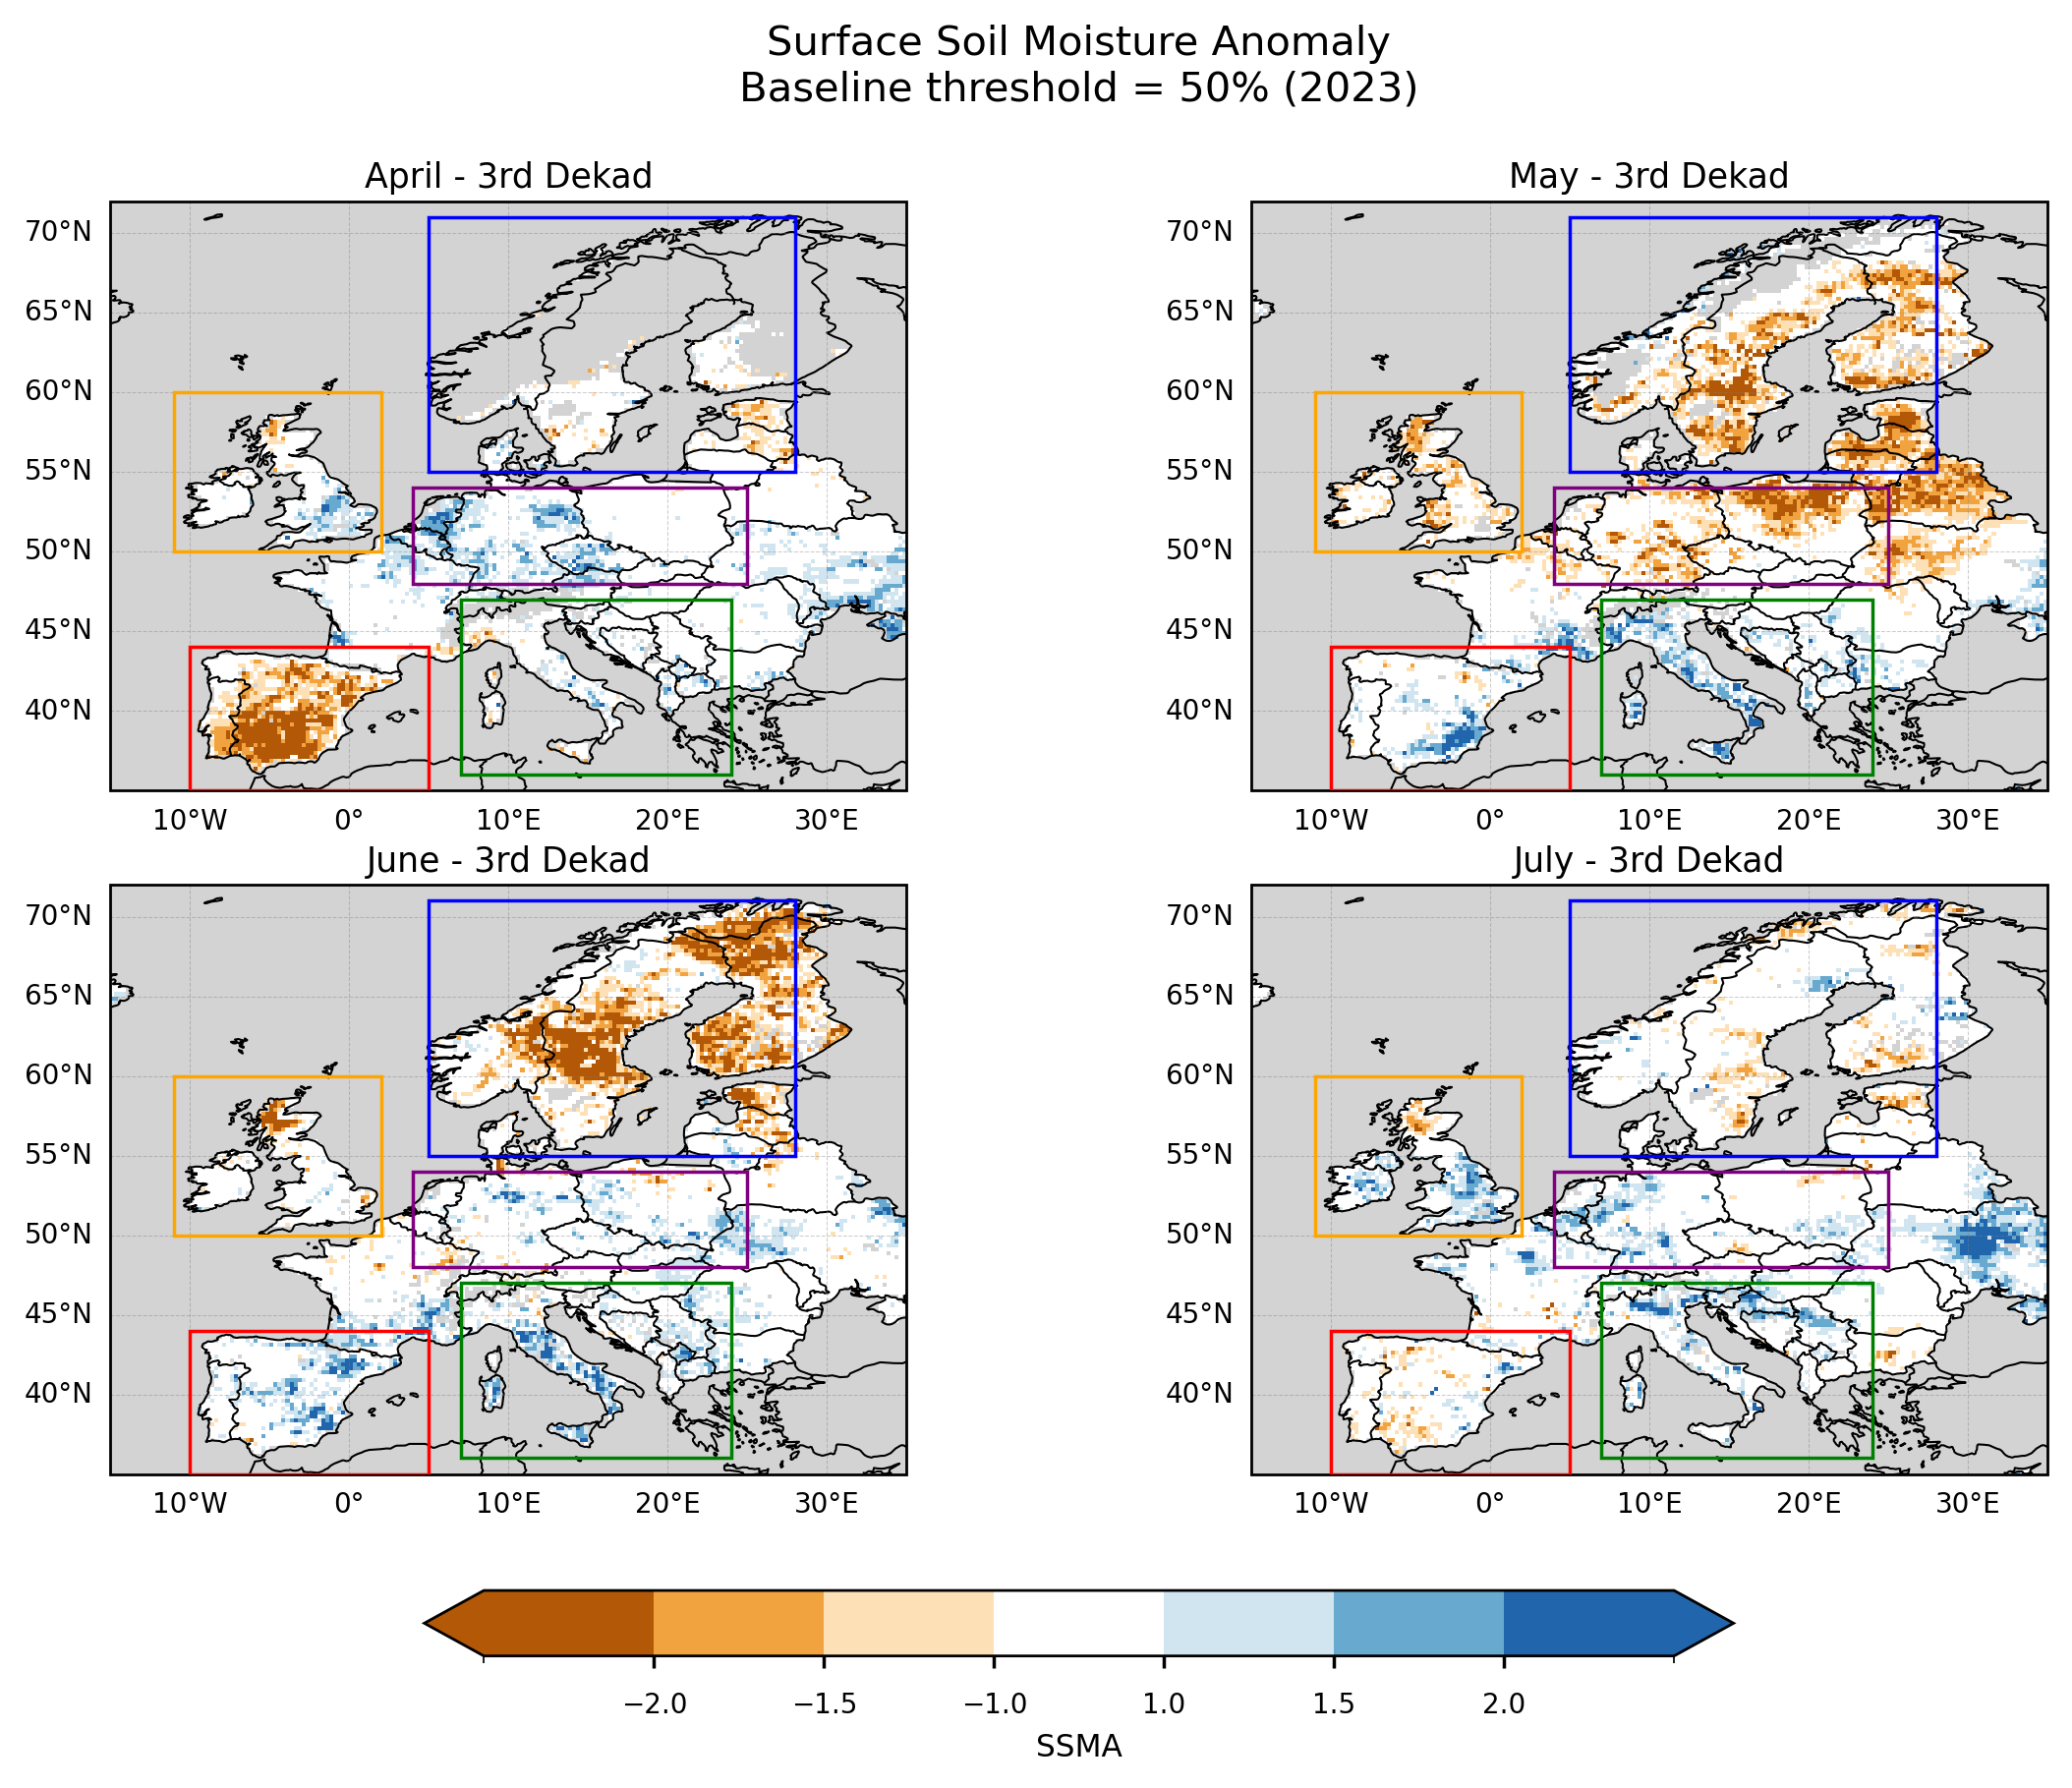

In [34]:
fig_05 = plot_ssma_selected_dekads(
    ssma=ssma_05,
    boxes=boxes,
    cmap=cmap,
    norm=norm,
    bounds=bounds,
    main_title="Surface Soil Moisture Anomaly\nBaseline threshold = 50%"
)
plt.show()

*Figure 4. SSMA over Europe for the third dekad of April, May, June, and July 2023. Anomalies are computed using a baseline completeness threshold of ≥50%. Boxes indicate the regions selected for subsequent regional analysis.*

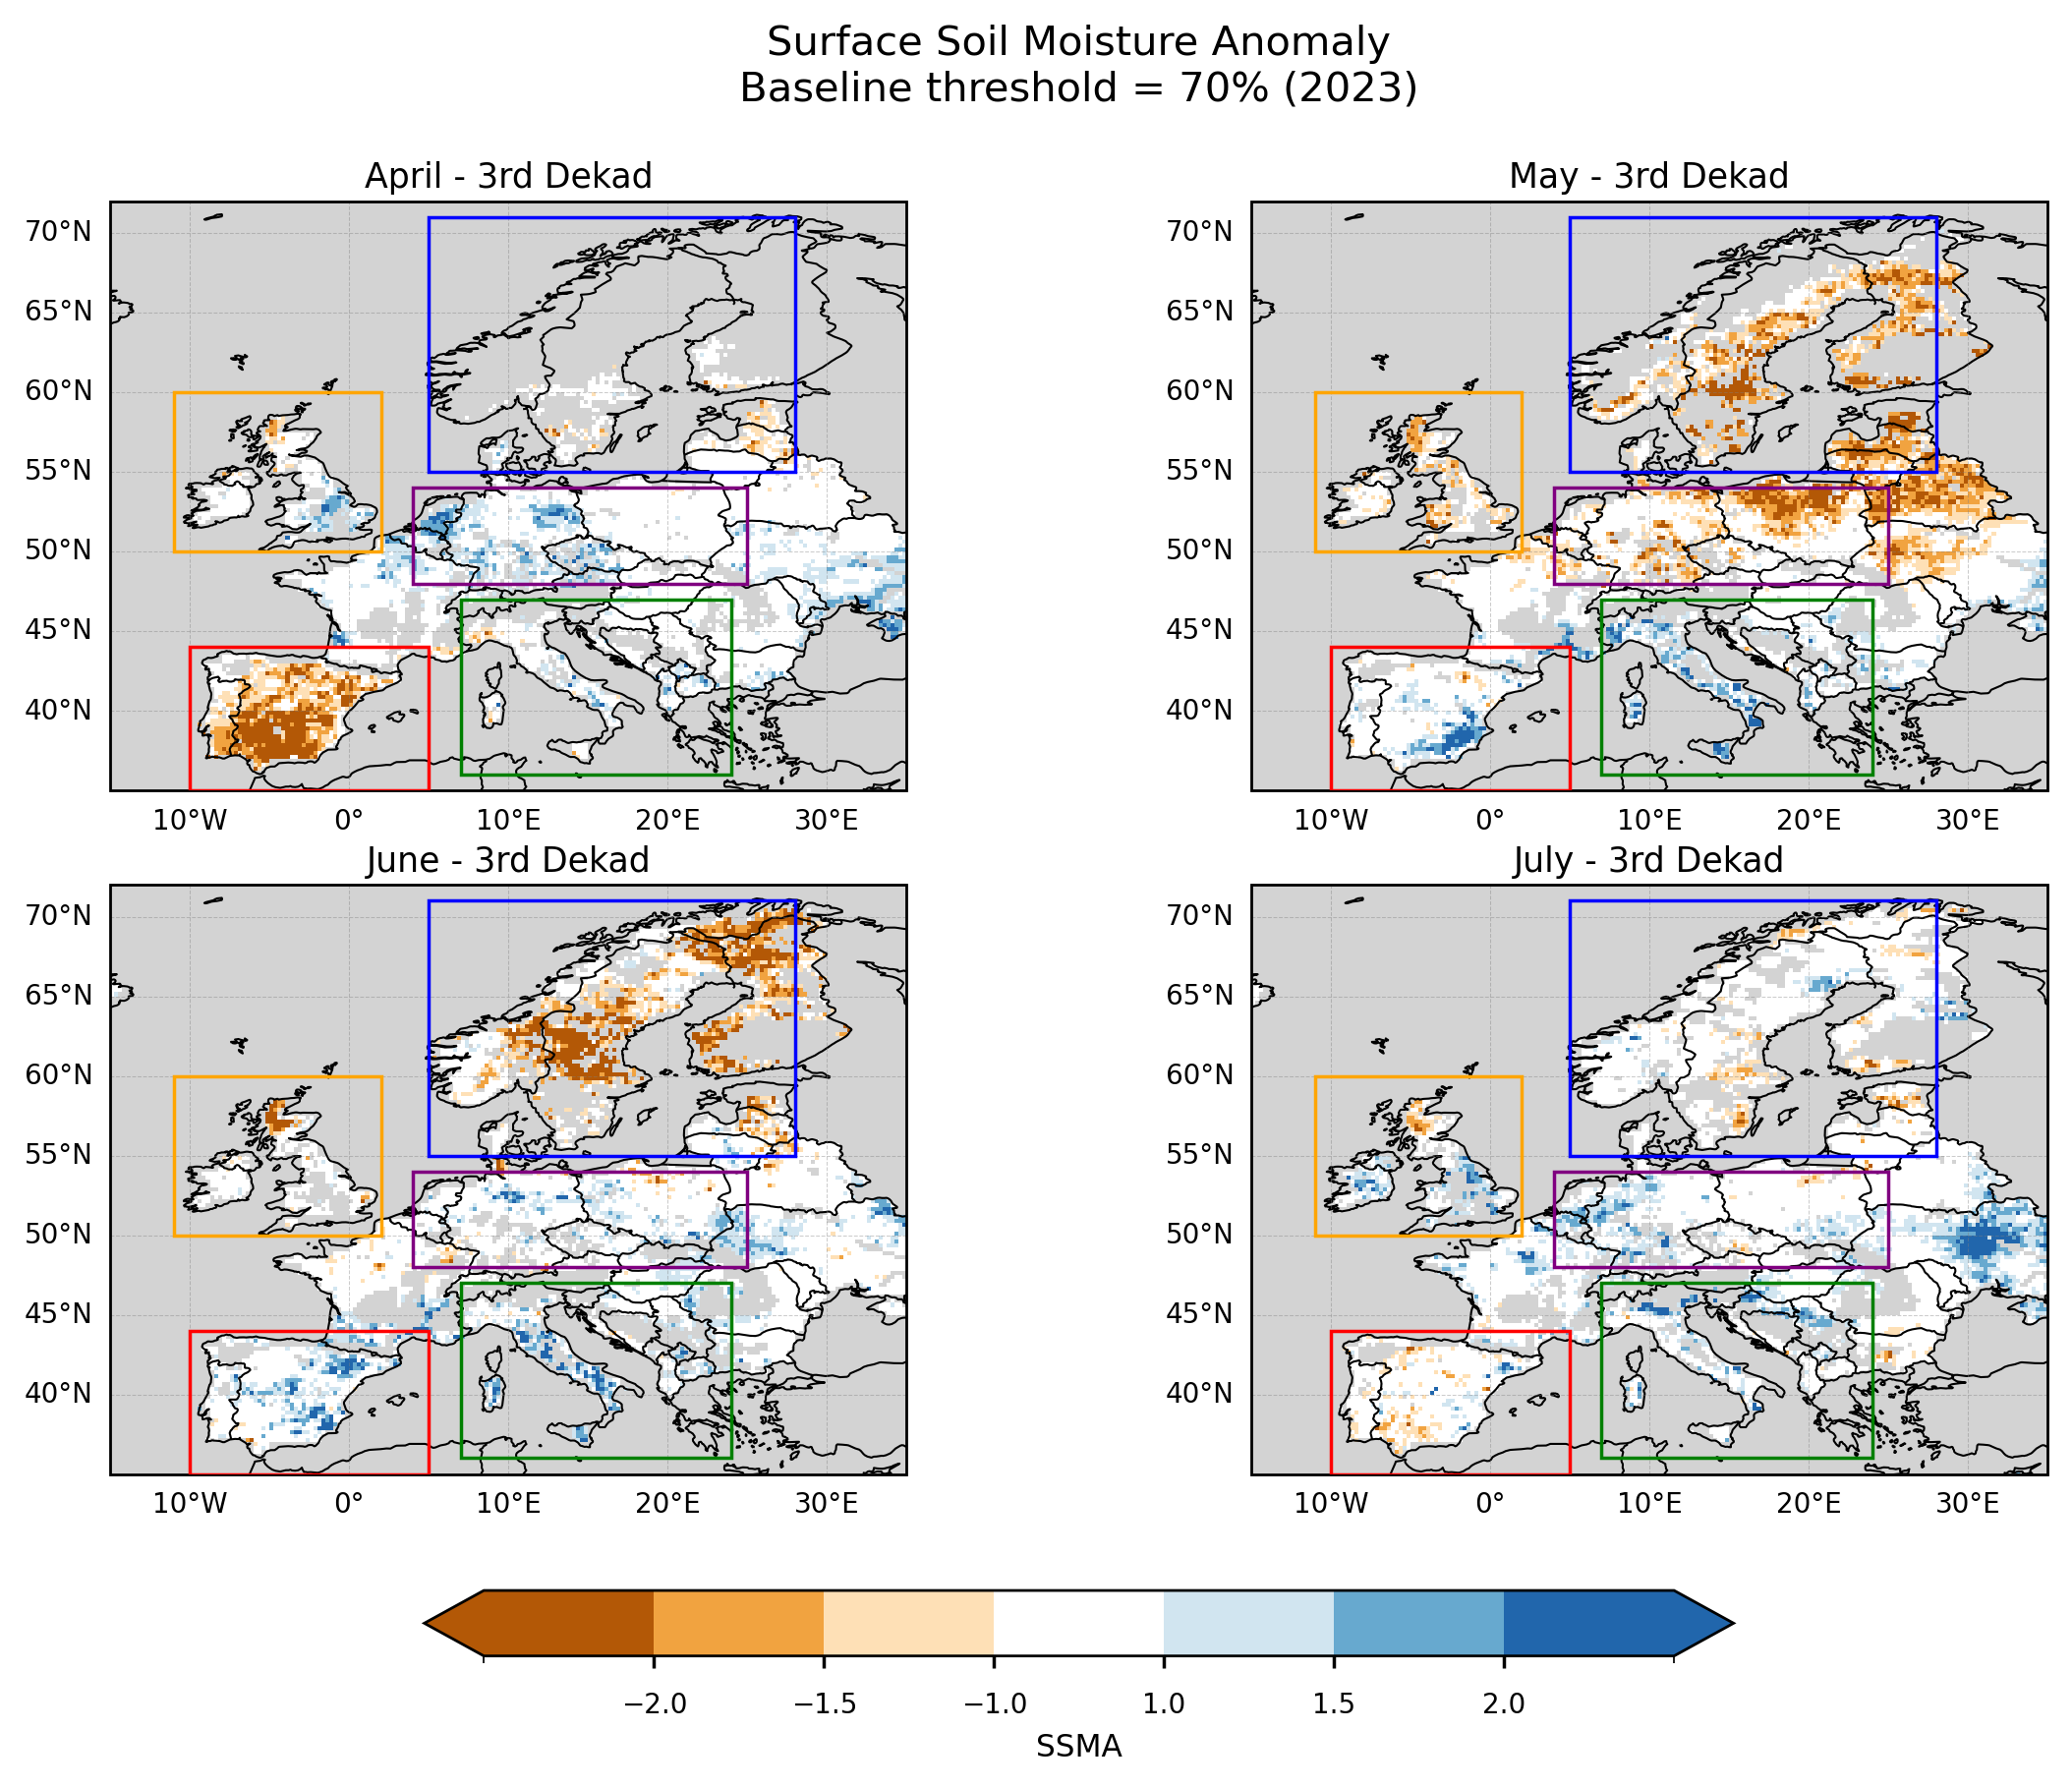

In [35]:
fig_07 = plot_ssma_selected_dekads(
    ssma=ssma_07,
    boxes=boxes,
    cmap=cmap,
    norm=norm,
    bounds=bounds,
    main_title="Surface Soil Moisture Anomaly\nBaseline threshold = 70%"
)
plt.show()

*Figure 5. SSMA over Europe for the third dekad of April, May, June, and July 2023. Anomalies are computed using a baseline completeness threshold of ≥70%. Boxes indicate the regions selected for subsequent regional analysis.*

![JRGaugust23.jpg](004a20bf-a633-43eb-b74a-9cbebdc4ce91.jpg)

*Figure 6. Soil Moisture Anomaly from April to July 2023. Extracted from: JRC (2023)[[6]](https://doi.org/10.2760/928418)*

The application of a baseline completeness threshold has a clear impact on the spatial coverage of the SSMA maps. Under the ≥70% threshold, missing values become more prominent in regions where long-term data availability is limited, particularly in areas with complex terrain such as the Pyrenees, Alps, Apennines, Dinaric Alps, Balkan Mountains, and Carpathians. Reduced coverage is also observed in parts of northern Spain and southern UK, potentially reflecting a combination of retrieval limitations over heterogeneous terrain and urban areas.

Compared to the no-threshold and ≥50% cases, the ≥70% threshold leads to a noticeable reduction in spatial coverage over southern and southeastern Europe, especially across Italy and the Balkans. In these regions, areas that appear as neutral or positive anomalies in the lower-threshold cases are masked out when stricter baseline requirements are applied. This highlights the sensitivity of the spatial patterns to baseline data availability.

Despite these differences, several large-scale features remain consistent with the patterns reported in the JRC drought analyses. In particular, persistent negative anomalies are observed across Scandinavia, and a transition towards more neutral or slightly positive anomalies is visible over parts of the British Isles in late July. This suggests that, even with reduced baseline support in some regions, the main spatial signals are broadly captured.

The largest discrepancies with respect to the JRC results are observed over central-western Europe (e.g. Benelux, Germany, and surrounding areas), where the satellite-based anomalies show weaker or more spatially fragmented drought signals. These differences may reflect both the sensitivity of surface soil moisture to short-term variability and the impact of data completeness on the anomaly calculation.

(satellite_satellite-soil-moisture_completeness_q02:section-6)=
### 6. Regional SSMA analysis

The following section computes and visualizes regional SSMA statistics for selected European subregions. For each region, SSMA values are spatially subsetted to the corresponding bounding box and restricted to land pixels using a geographic mask. The analysis focuses on the period from March to August 2023, using dekadal time steps.

This period was selected to capture the onset, development, and peak of the 2023 European drought, while maintaining consistency with the temporal coverage of the JRC drought reports, which provide assessments for March [[3]](https://doi.org/10.2760/998985), June [[5]](https://doi.org/10.2760/575433), and August [[6]](https://doi.org/10.2760/928418). Focusing on this interval allows for a targeted evaluation of the dataset’s ability to represent the main phases of the drought event, while avoiding the inclusion of less relevant periods outside the core drought season.

Within each region and dekad, the distribution of SSMA across all land pixels is summarized using the median and interquartile range (IQR; 25th–75th percentiles), providing a robust representation of central tendency and spatial variability. In parallel, data completeness is quantified as the percentage of valid (non-missing) land pixels contributing to each dekad.

These statistics are computed separately for different baseline completeness thresholds (no threshold, ≥50%, ≥70%) to assess the sensitivity of the SSMA signal to data availability. The resulting time series are displayed as multi-panel figures, allowing direct comparison of SSMA behaviour and completeness across thresholds and regions.

In [38]:
def _prepare_region_ssma_stats(
    ssma_data: xr.DataArray,
    box: dict,
    europe_shape,
    start_doy=60,
    end_doy=233,
    year=2023,
):
    """
    Prepare regional SSMA statistics over land pixels only.

    Returns
    -------
    date_index : pandas.DatetimeIndex
    median_ssma : xr.DataArray
    q25_ssma : xr.DataArray
    q75_ssma : xr.DataArray
    completeness_perc : xr.DataArray
    """
    # Subset region
    ssma_subset = ssma_data.sel(
        longitude=slice(box["min_lon"], box["max_lon"]),
        latitude=slice(box["max_lat"], box["min_lat"])  # latitude descending
    )

    # Subset time
    available_doys = ssma_subset.dayofyear.values
    target_doys = [doy for doy in available_doys if start_doy <= doy <= end_doy]
    if not target_doys:
        raise ValueError(f"No matching DOYs in range {start_doy}–{end_doy}.")

    ssma_subset = ssma_subset.sel(dayofyear=target_doys)

    # Land mask
    dummy = xr.full_like(ssma_subset.isel(dayofyear=0), fill_value=1)
    dummy = dummy.rio.write_crs("EPSG:4326")

    clipped = dummy.rio.clip(europe_shape.geometry, europe_shape.crs, drop=False)
    land_mask = clipped.notnull()

    total_land_pixels = int(land_mask.sum().compute().item())
    if total_land_pixels == 0:
        raise ValueError(f"No land pixels found in {box['label']}.")

    # Keep only land pixels
    ssma_land = ssma_subset.where(land_mask)

    # Stack spatial dims
    stacked = ssma_land.stack(pixel=("latitude", "longitude"))

    median_ssma = stacked.median(dim="pixel", skipna=True).compute()
    q25_ssma = stacked.quantile(0.25, dim="pixel", skipna=True).compute()
    q75_ssma = stacked.quantile(0.75, dim="pixel", skipna=True).compute()

    # Completeness over land only
    valid_mask = ssma_land.notnull()
    valid_count = valid_mask.sum(dim=["latitude", "longitude"]).compute()
    completeness_perc = (valid_count / total_land_pixels * 100).compute()

    # Dates
    date_index = pd.to_datetime(
        [f"{year}-{doy}" for doy in ssma_subset.dayofyear.values],
        format="%Y-%j"
    )

    return date_index, median_ssma, q25_ssma, q75_ssma, completeness_perc


def plot_ssma_median_iqr_three_panels(
    ssma_list,
    panel_titles,
    box: dict,
    europe_shape,
    start_doy=60,
    end_doy=233,
    year=2023,
    figsize=(16, 4.5),
    suptitle=None,
):
    """
    Plot 3 side-by-side panels of regional SSMA over land pixels only:
    - median line
    - IQR shading (25th–75th percentile)
    - completeness (%) on a secondary axis

    Parameters
    ----------
    ssma_list : list of xr.DataArray
        Typically [ssma_none, ssma_05, ssma_07] or similar.
    panel_titles : list of str
        Titles for each panel, same length as ssma_list.
    box : dict
        Region definition with keys:
        min_lon, max_lon, min_lat, max_lat, label, color
    europe_shape : geopandas.GeoDataFrame
        Land geometry used to mask oceans.
    start_doy, end_doy : int
        Day-of-year range to plot.
    year : int
        Year used to convert DOY to dates.
    figsize : tuple
        Figure size.
    suptitle : str or None
        Optional overall title.
    """
    if len(ssma_list) != 3:
        raise ValueError("This function expects exactly 3 SSMA DataArrays.")
    if len(panel_titles) != 3:
        raise ValueError("Please provide exactly 3 panel titles.")

    fig, axes = plt.subplots(1, 3, figsize=figsize, dpi=250, sharey=True)

    color = box.get("color", "blue")
    label = box.get("label", "Region")

    for i, (ax, ssma_data, panel_title) in enumerate(zip(axes, ssma_list, panel_titles)):
        date_index, median_ssma, q25_ssma, q75_ssma, completeness_perc = _prepare_region_ssma_stats(
            ssma_data=ssma_data,
            box=box,
            europe_shape=europe_shape,
            start_doy=start_doy,
            end_doy=end_doy,
            year=year,
        )

        # Left axis: median + IQR
        ax.plot(
            date_index,
            median_ssma.values,
            marker="o",
            linestyle="-",
            color=color,
            linewidth=1.5,
            label="Median SSMA"
        )
        ax.fill_between(
            date_index,
            q25_ssma.values,
            q75_ssma.values,
            color=color,
            alpha=0.25,
            label="IQR"
        )
        ax.axhline(0, color="black", linestyle="--", linewidth=1)

        ax.set_title(panel_title)
        ax.set_xlabel("Date")

        if i == 0:
            ax.set_ylabel("SSMA")

        # Right axis: completeness
        ax2 = ax.twinx()
        ax2.plot(
            date_index,
            completeness_perc.values,
            color="gray",
            linestyle="--",
            marker="x",
            linewidth=1.2,
            label="% Completeness"
        )
        ax2.set_ylim(0, 100)

        if i == 2:
            ax2.set_ylabel("% Completeness (land only)")
        else:
            ax2.set_ylabel("")

        # X ticks on dekad starts
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
        plt.setp(ax.get_xticklabels(), rotation=0)

        # Only one combined legend, placed in first panel
        if i == 0:
            lines1, labels1 = ax.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=8)

    if suptitle is None:
        suptitle = (
            f"{label}: regional SSMA across land pixels only\n"
            f"Median and interquartile range, {date_index[0].strftime('%b %d')}–{date_index[-1].strftime('%b %d')}"
        )

    fig.suptitle(suptitle, y=1.03)
    plt.tight_layout()
    plt.show()

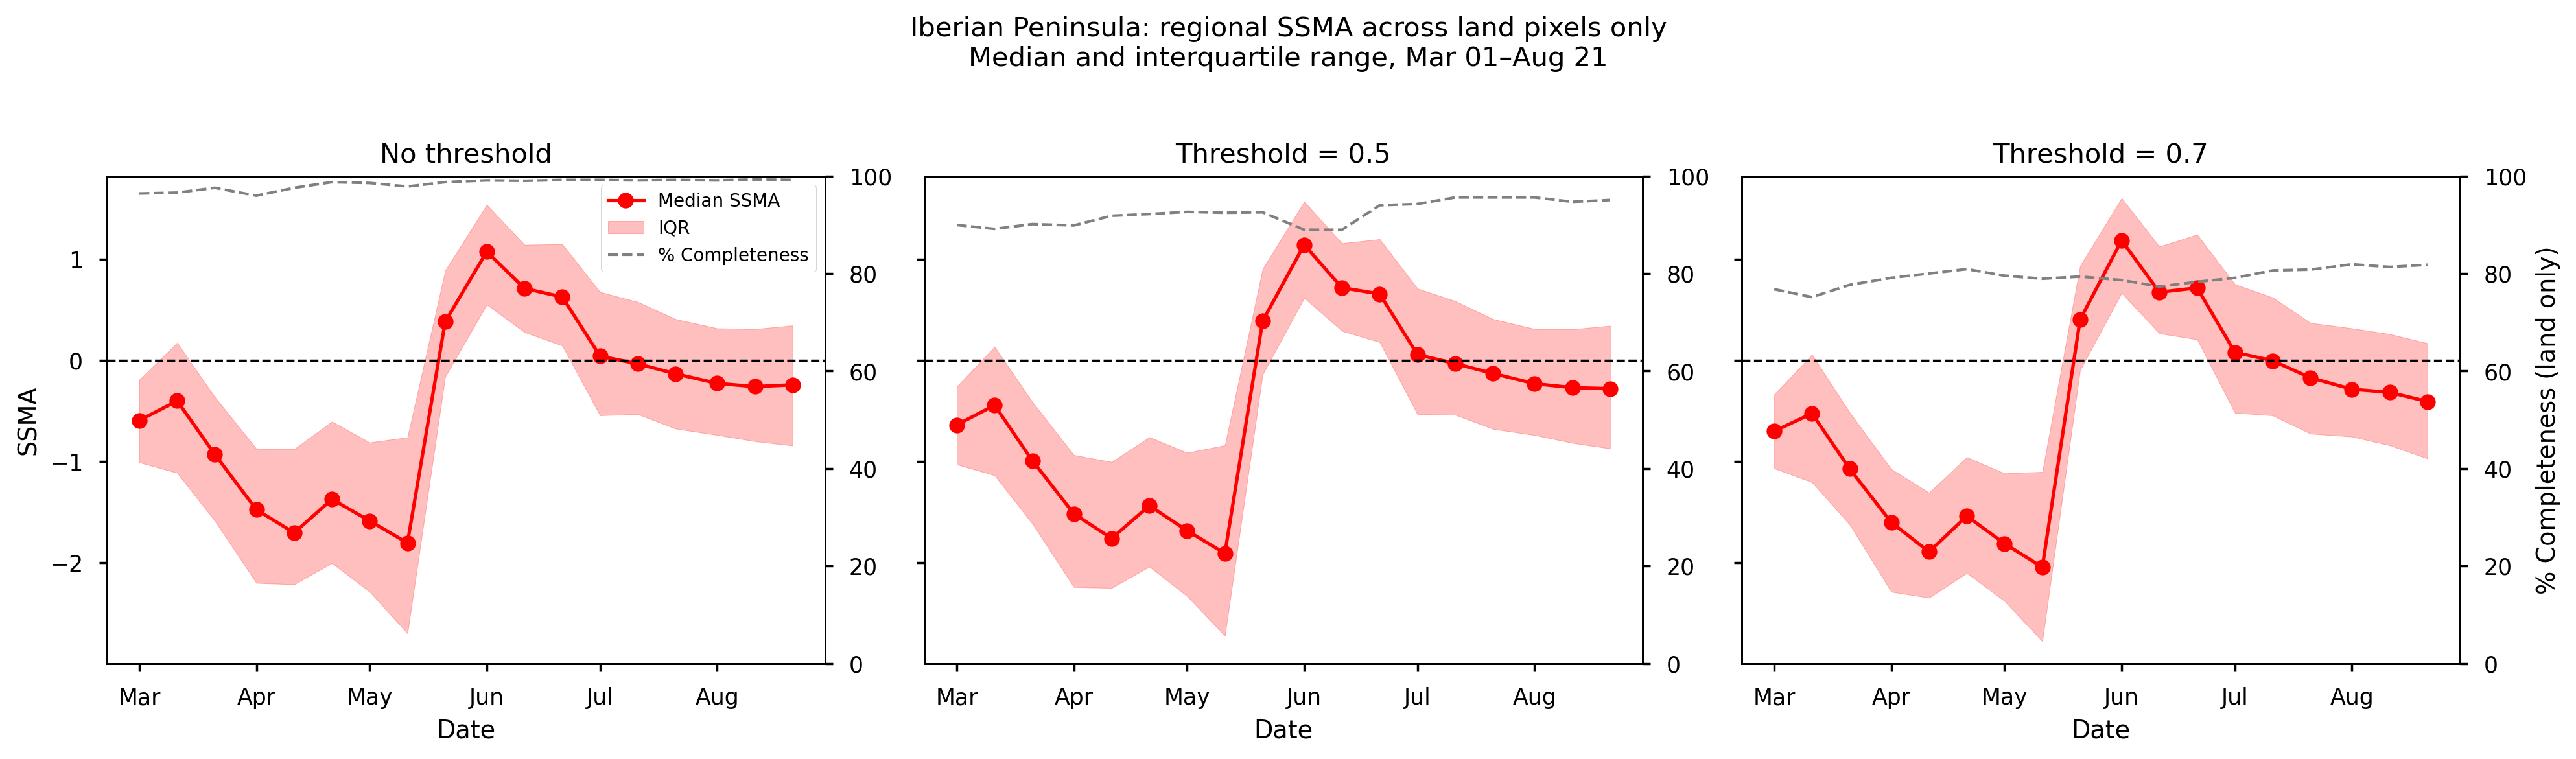

In [39]:
plot_ssma_median_iqr_three_panels(
    ssma_list=[ssma_none, ssma_05, ssma_07],
    panel_titles=["No threshold", "Threshold = 0.5", "Threshold = 0.7"],
    box=boxes[0],  # Iberian Peninsula
    europe_shape=europe_shape,
    start_doy=60,   # March 1st dekad
    end_doy=233,    # August 3rd dekad
)

*Figure 7. Mean SSMA over the Iberian Peninsula from spring to summer 2023, together with the corresponding data completeness (%). Panels (left to right) show results for different completeness thresholds: no threshold, ≥50%, and ≥70%.*

Over the Iberian Peninsula, SSMA shows a clear seasonal evolution, with the most negative values occurring in mid-May, followed by a rapid transition towards positive anomalies in early June and a gradual stabilization towards near-neutral conditions during July and August. This pattern reflects the transition from peak drought conditions in late spring to partial recovery in early summer.

The temporal evolution of the median SSMA is highly consistent across all completeness thresholds, with only minor differences in magnitude. This indicates that the regional drought signal is robust to the choice of baseline filtering.

Data completeness remains high throughout the period. For the no-threshold and ≥50% cases, completeness exceeds 90% across most dekads, indicating strong spatial support. The ≥70% threshold results in slightly lower completeness (around 80%), but still maintains sufficient coverage to support the analysis.

Overall, the strong agreement across thresholds, combined with high data availability, suggests that the SSMA estimates for the Iberian Peninsula are both stable and well-supported by the underlying data.

This evolution is consistent with the progression of drought conditions reported for the western Mediterranean in spring 2023, followed by partial recovery in early summer [[3]](https://doi.org/10.2760/998985), [[5]](https://doi.org/10.2760/575433), [[6]](https://doi.org/10.2760/928418), [[7]](https://joint-research-centre.ec.europa.eu/jrc-news-and-updates/severe-drought-western-mediterranean-faces-low-river-flows-and-crop-yields-earlier-ever-2023-06-13_en), [[8]](https://climate.copernicus.eu/precipitation-relative-humidity-and-soil-moisture-may-2023), and with studies highlighting the role of persistent soil moisture deficits in amplifying the record-breaking spring heatwave in the region [[9]](https://doi.org/10.1038/s41612-024-00569-6).

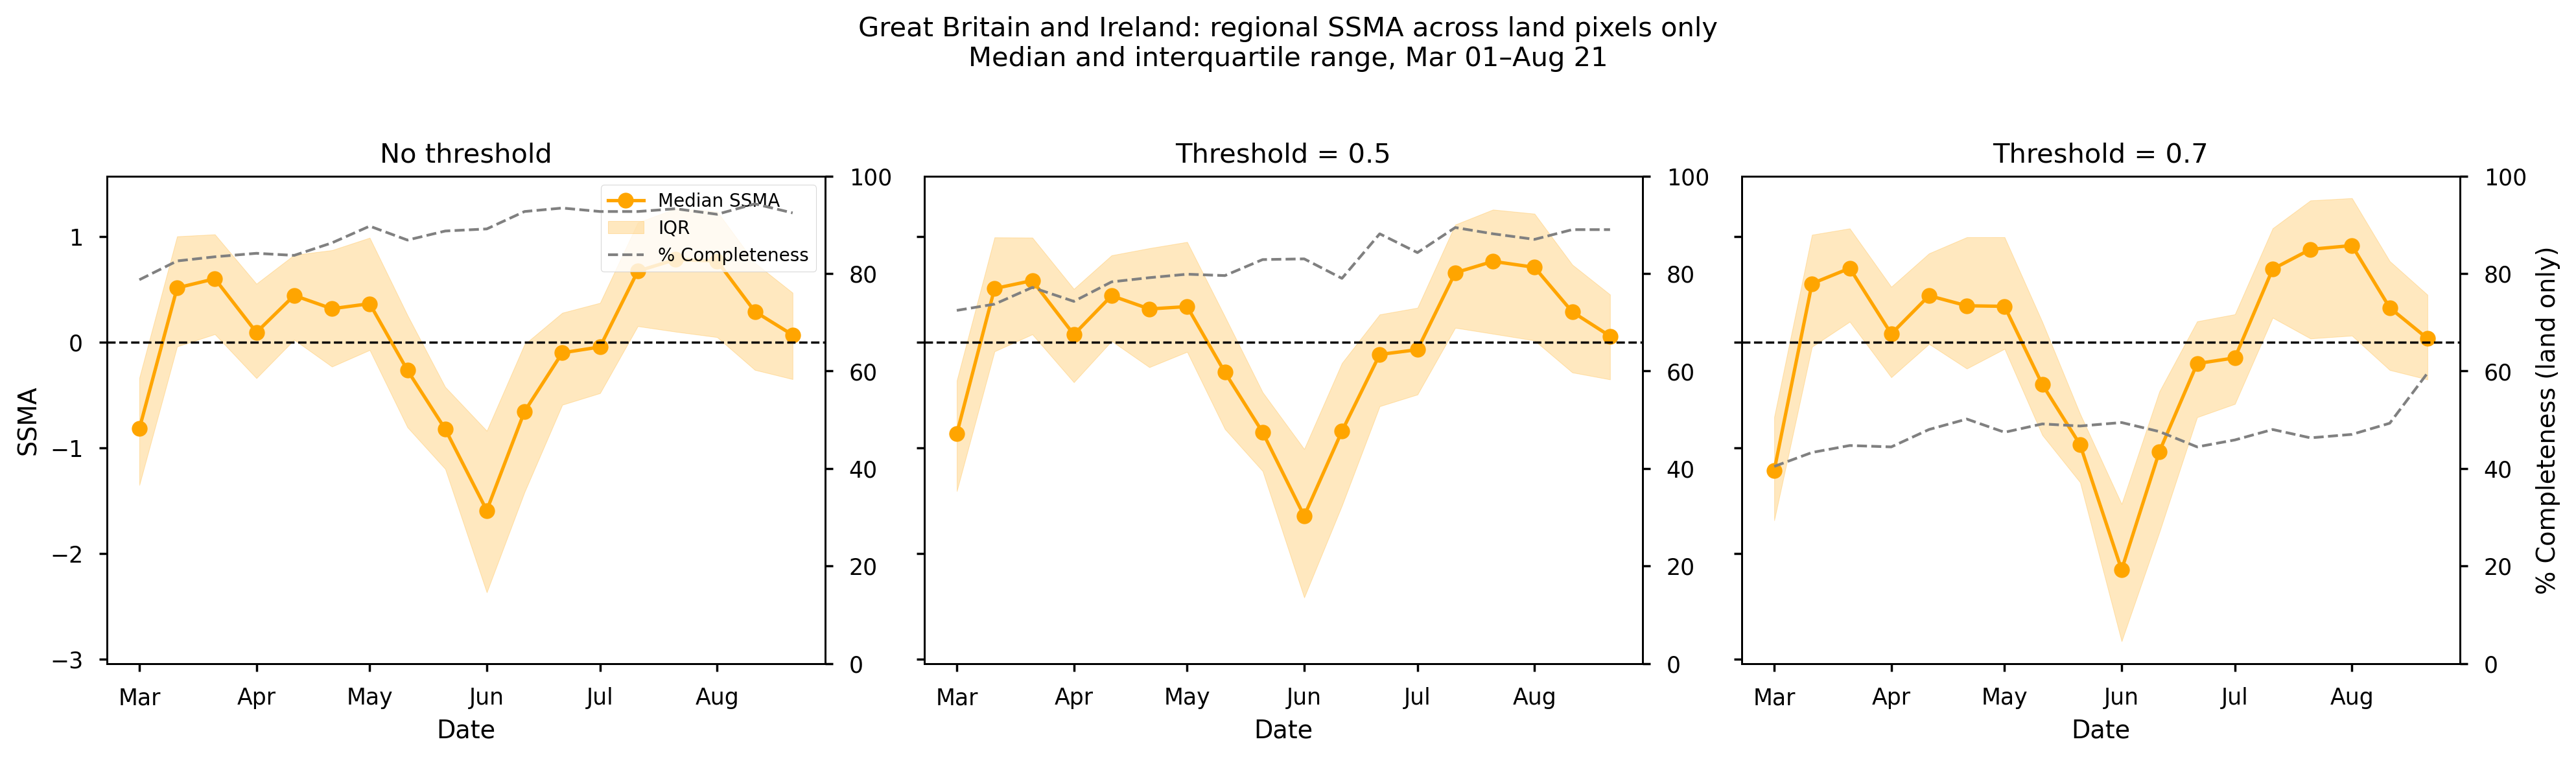

In [40]:
plot_ssma_median_iqr_three_panels(
    ssma_list=[ssma_none, ssma_05, ssma_07],
    panel_titles=["No threshold", "Threshold = 0.5", "Threshold = 0.7"],
    box=boxes[1],
    europe_shape=europe_shape,
    start_doy=60,   # March 1st dekad
    end_doy=233,    # August 3rd dekad
)

*Figure 8. Mean SSMA over Great Britain and Ireland from spring to summer 2023, together with the corresponding data completeness (%). Panels (left to right) show results for different completeness thresholds: no threshold, ≥50%, and ≥70%.*

Over Great Britain and Ireland, SSMA exhibits a clear minimum in June, indicating the peak of dry conditions, followed by a gradual recovery towards neutral and slight possitive anomalies conditions in July and August. The magnitude of the negative anomaly is slightly stronger when applying the ≥70% threshold, suggesting that stricter filtering removes pixels with limited baseline support, which can reduce noise and result in slightly stronger anomaly signals.

Data completeness remains high (>80%) for both the no-threshold and ≥50% cases, indicating robust spatial support. In contrast, the ≥70% threshold leads to a substantial reduction in completeness (approximately 40–60%), reflecting limited baseline availability in parts of the region. Despite this reduction, the temporal evolution of SSMA remains consistent across thresholds, indicating that the main drought signal is stable.

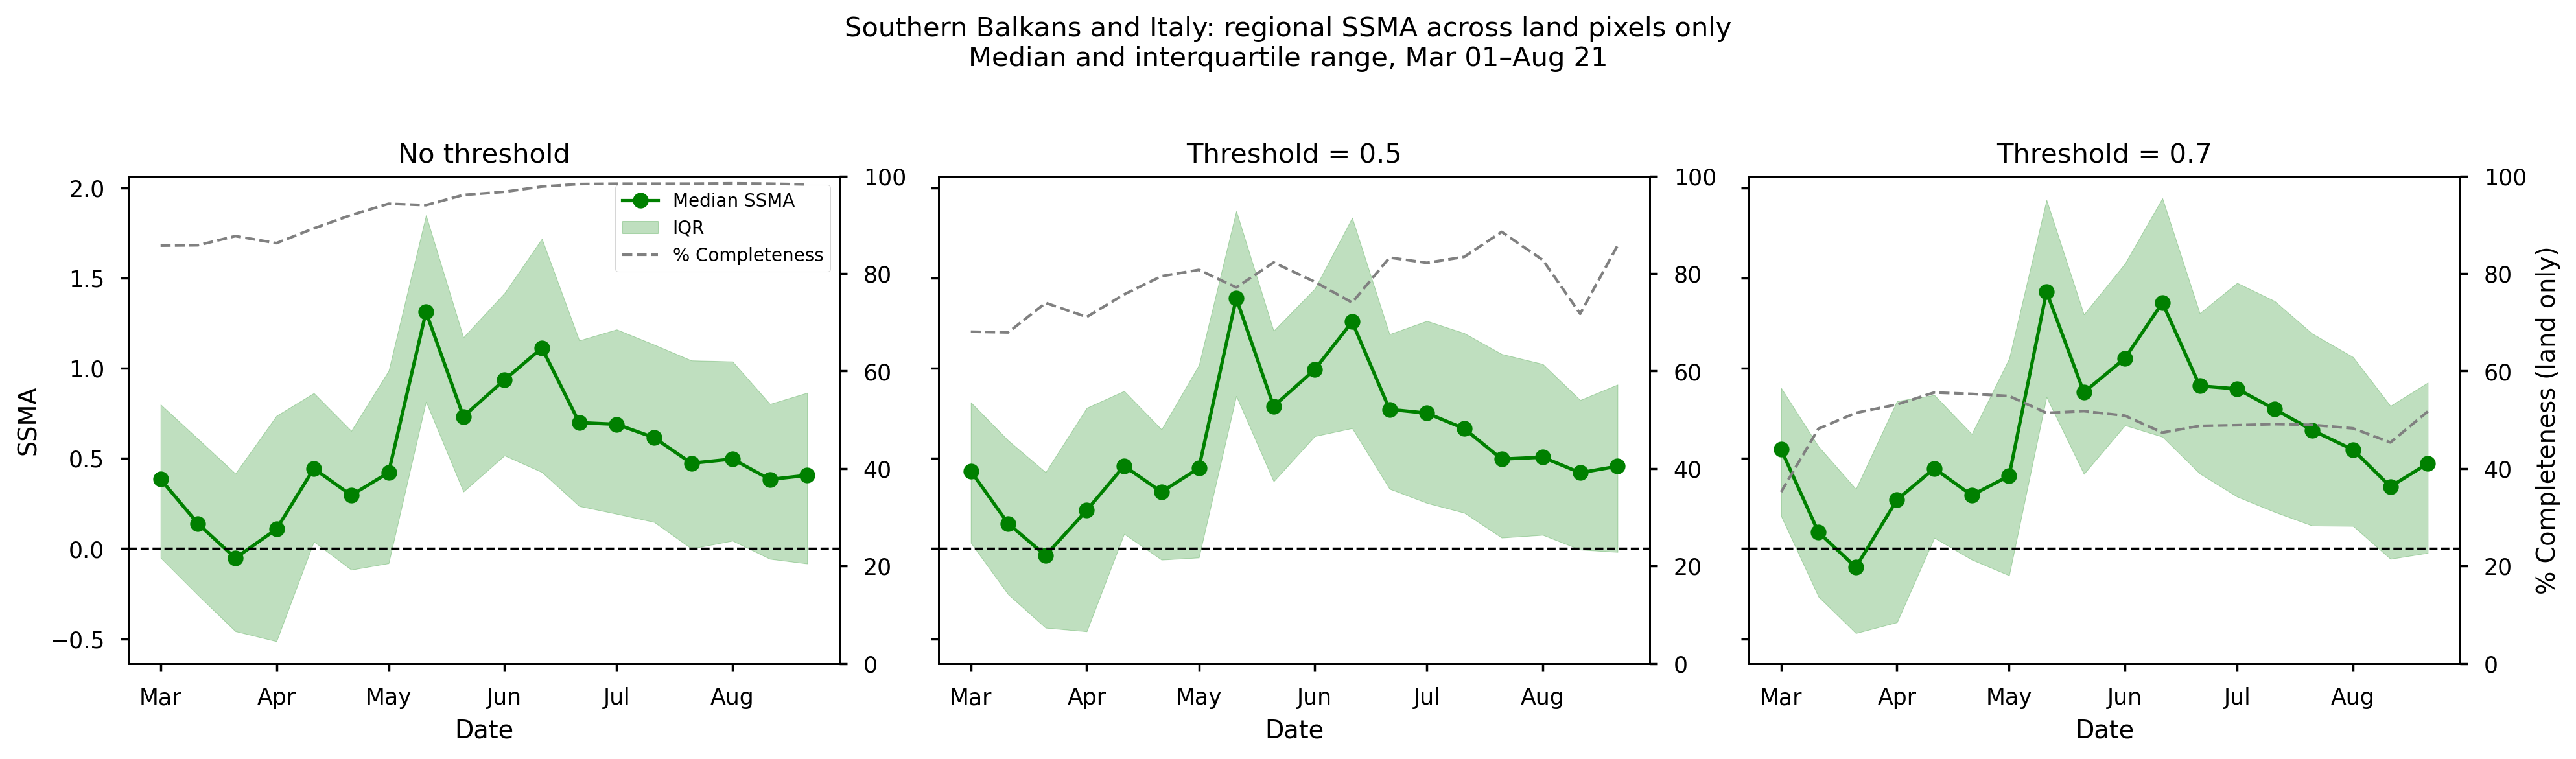

In [41]:
plot_ssma_median_iqr_three_panels(
    ssma_list=[ssma_none, ssma_05, ssma_07],
    panel_titles=["No threshold", "Threshold = 0.5", "Threshold = 0.7"],
    box=boxes[2],
    europe_shape=europe_shape,
    start_doy=60,   # March 1st dekad
    end_doy=233,    # August 3rd dekad
)

*Figure 9. Mean SSMA over the Southern Balkans and Italy from spring to summer 2023, together with the corresponding data completeness (%). Panels (left to right) show results for different completeness thresholds: no threshold, ≥50%, and ≥70%.*

In the Southern Balkans and Italy, SSMA is predominantly positive throughout the analysis period, with peaks in mid-May and mid-June. This behaviour contrasts with drought-affected regions and is consistent with spatial patterns observed in the maps. This positive anomaly is consistent with reported rainfall surpluses in May and June over Italy, as well as parts of Slovakia, Hungary, Croatia, and Slovenia, which led to waterlogging of soils and increased pest pressure on crops [[10]](https://doi.org/10.2760/82821).

Completeness shows a stronger dependence on the applied threshold. While the no-threshold case increases from ~80% to near-complete coverage over time, the ≥50% threshold introduces moderate variability around ~80%. The ≥70% threshold results in lower and more stable completeness (approximately 40–60%), with slightly higher values in early spring.

Despite these differences in data availability, the SSMA signal remains largely unchanged across thresholds, indicating that the positive anomaly pattern is robust.

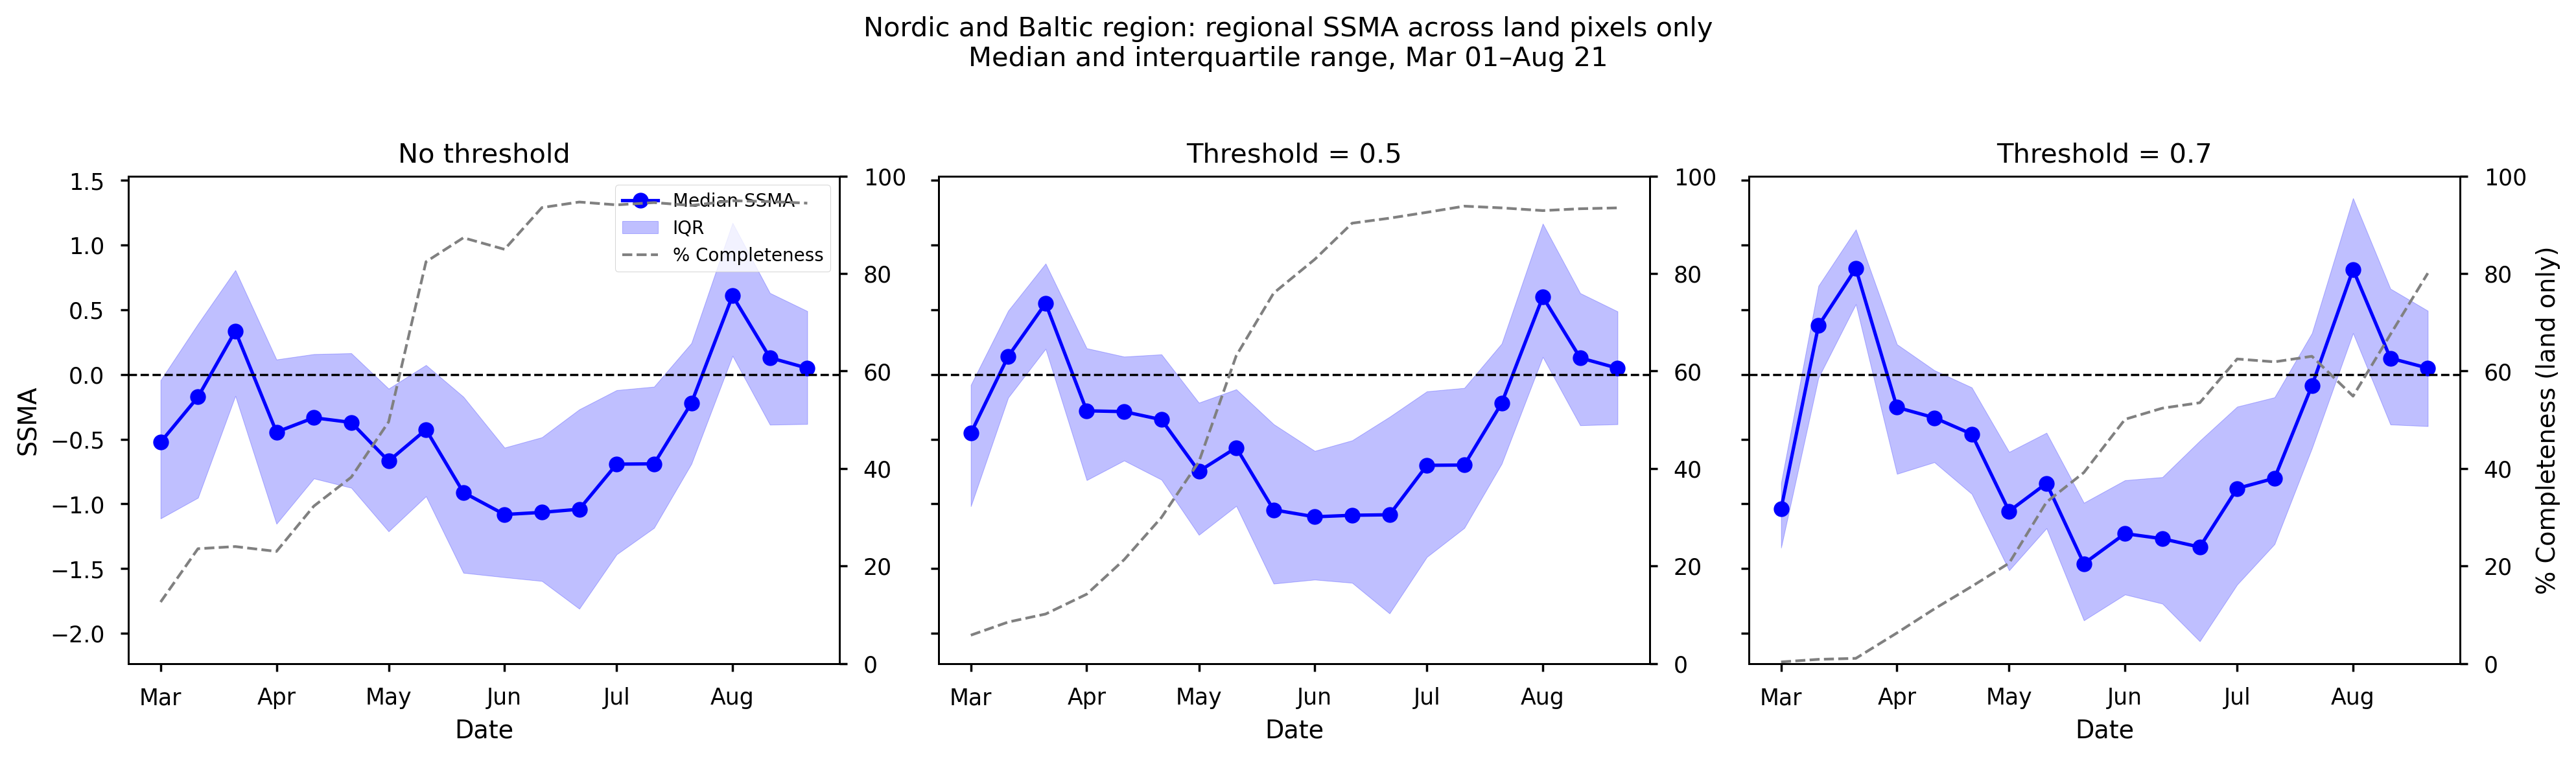

In [42]:
plot_ssma_median_iqr_three_panels(
    ssma_list=[ssma_none, ssma_05, ssma_07],
    panel_titles=["No threshold", "Threshold = 0.5", "Threshold = 0.7"],
    box=boxes[3],
    europe_shape=europe_shape,
    start_doy=60,   # March 1st dekad
    end_doy=233,    # August 3rd dekad
)

*Figure 10. Mean SSMA over the Nordic and Baltic region from spring to summer 2023, together with the corresponding data completeness (%). Panels (left to right) show results for different completeness thresholds: no threshold, ≥50%, and ≥70%.*

The Nordic and Baltic region shows a pronounced seasonal evolution, with the lowest SSMA values occurring in June and a transition to slight positive anomalies by early August. The magnitude of negative anomalies is slightly enhanced under the ≥70% threshold.

Completeness exhibits a strong seasonal increase, rising from very low values (<20%) in early spring to high values (>80%) in summer. This pattern is consistent across thresholds, although the ≥70% threshold delays the point at which sufficient coverage is reached (crossing ~60% only in early July). This behaviour reflects known limitations in satellite soil moisture retrievals under snow and frozen soil conditions.

Despite the strong variation in completeness, the temporal SSMA pattern remains consistent across thresholds once sufficient data coverage is achieved.

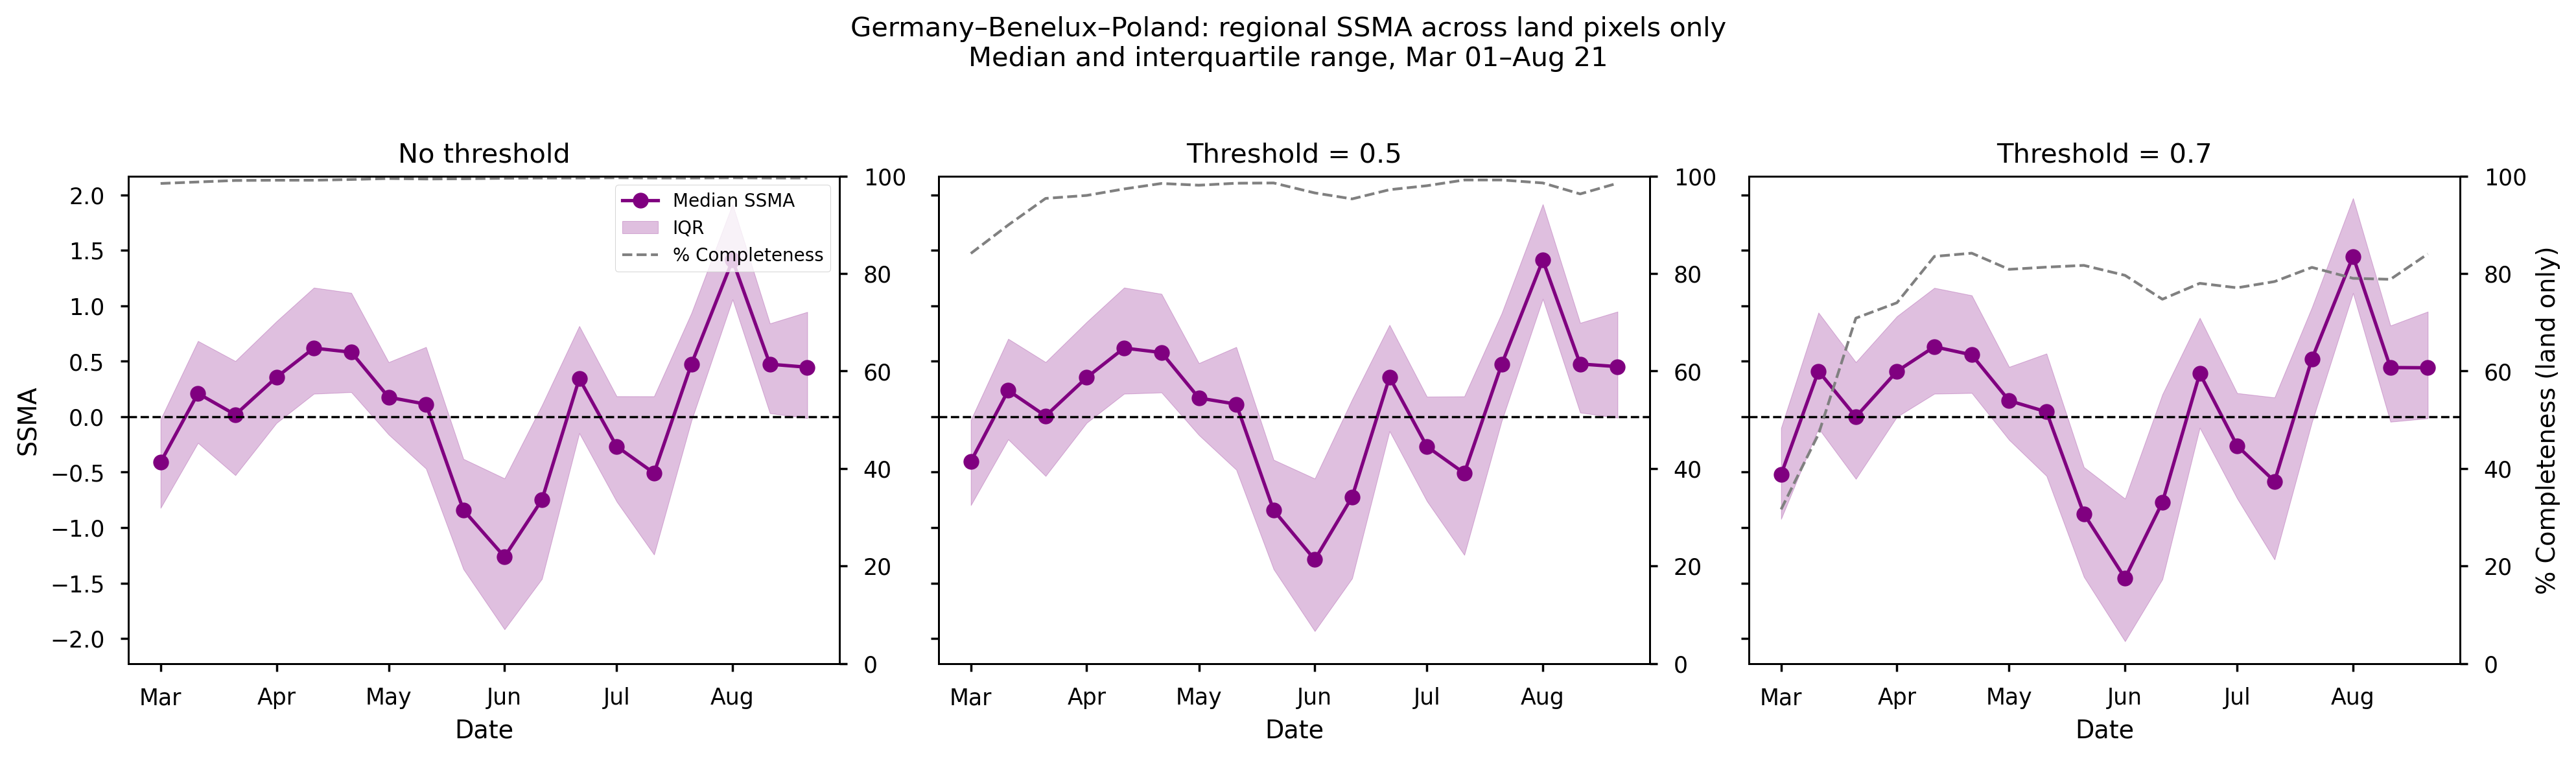

In [43]:
plot_ssma_median_iqr_three_panels(
    ssma_list=[ssma_none, ssma_05, ssma_07],
    panel_titles=["No threshold", "Threshold = 0.5", "Threshold = 0.7"],
    box=boxes[4],
    europe_shape=europe_shape,
    start_doy=60,   # March 1st dekad
    end_doy=233,    # August 3rd dekad
)

*Figure 11. Mean SSMA over the Germany–Benelux–Poland area from spring to summer 2023, together with the corresponding data completeness (%). Panels (left to right) show results for different completeness thresholds: no threshold, ≥50%, and ≥70%.*

In the Germany–Benelux–Poland region, SSMA reaches its minimum in early June and transitions to positive anomalies by early August. Compared to other regions, this area shows greater sensitivity to threshold selection, particularly in early spring.

Completeness is near-total (≈100%) in the no-threshold case and remains high (>90%) for the ≥50% threshold. Under the ≥70% threshold, completeness is initially low (~40% in early March) but increases rapidly, stabilizing around ~80% for the remainder of the period.

Across all regions, the median SSMA and its temporal evolution are broadly consistent across the different completeness thresholds, despite substantial differences in data availability. This indicates that the main drought signal is relatively robust to the choice of threshold. However, stricter thresholds (e.g. ≥70%) significantly reduce spatial coverage in several regions, particularly where baseline data availability is limited.

The close agreement between the no-threshold and ≥50% cases indicates that applying a 50% completeness requirement does not materially change the baseline composition. This is likely due to the uneven temporal distribution of valid observations, with a higher density of data in more recent years following the introduction of additional sensors (e.g. AMSR-E and ASCAT). Consequently, the ≥50% threshold effectively selects pixels for which a sufficient number of valid years is already concentrated in the later part of the record, leading to an overrepresentation of recent conditions in the baseline and a reduced contribution from earlier, less complete years.

## ℹ️ If you want to know more

* Markonis, Y., Kumar, R., Hanel, M., Rakovec, O., Máca, P., & AghaKouchak, A. (2021). The rise of compound warm-season droughts in Europe. Science Advances, 7(6), eabb9668. [](https://doi.org/10.1126/sciadv.abb9668)
* Ministerio para la Transición Ecológica y el Reto Demográfico (2023). El 14,6% del territorio está en emergencia por escasez de agua y el 27,4%, en alerta. Nota de prensa. [](https://www.miteco.gob.es/es/prensa/ultimas-noticias/2023/09/el-14-6--del-territorio-esta-en-emergencia-por-escasez-de-agua-y.html)
* Laguardia, G. & Niemeyer, S. (2008). On the comparison between the LISFLOOD modelled and the ERS/SCAT derived soil moisture estimates. Hydrol. Earth Syst. Sci., 12, 1339–1351. [](https://doi.org/10.5194/hess-12-1339-2008)

### Key resources

Code libraries used:
* [C3S EQC custom functions](https://github.com/bopen/c3s-eqc-automatic-quality-control/tree/main/c3s_eqc_automatic_quality_control), `c3s_eqc_automatic_quality_control`,  prepared by [B-Open](https://www.bopen.eu/)

Dataset documentation:

* [SM v202212: Product User Guide and Specification (PUGS)](https://confluence.ecmwf.int/pages/viewpage.action?pageId=355349314)

* [SM v202312: Algorithm Theoretical Basis Document (ATBD)](https://confluence.ecmwf.int/pages/viewpage.action?pageId=453676750)

* [SM v202312: Product Quality Assurance Document (PQAD)](https://confluence.ecmwf.int/pages/viewpage.action?pageId=445290971)

* [SM v202312: Product Quality Assessment Report (PQAR)](https://confluence.ecmwf.int/x/6JiKGg)

### References

[[1]](https://ec.europa.eu/eurostat/web/gisco/geodata/administrative-units) Eurostat (Accessed on 2016). GISCO. Administrative units.

[[2]](https://community.wmo.int/site/knowledge-hub/programmes-and-initiatives/climate-services/wmo-climatological-normals)) World Meteorological Organization. (Accessed on 2016). WMO Climatological Normals.

[[3]](https://doi.org/10.2760/998985) Toreti, A., Bavera, D., Acosta Navarro, J., Arias Muñoz, C., Avanzi, F., Barbosa, P., de Jager, A., Di Ciollo, C., Ferraris, L., Fioravanti, G., Gabellani, S., Grimaldi, S., Hrast Essenfelder, A., Isabellon, M., Jonas, T., Maetens, W., Magni, D., Masante, D., Mazzeschi, M., McCormick, N., Meroni, M., Rossi, L., Salamon, P., Spinoni, J. (2023). Drought in Europe March 2023. Publications Office of the European Union, Luxembourg, doi:10.2760/998985, JRC133025.

[[4]](https://drought.emergency.copernicus.eu/data/factsheets/factsheet_soilmoisture.pdf) European Commission (2019). EDO INDICATOR FACTSHEET Soil Moisture Anomaly (SMA). European Drought Observatory.

[[5]](https://doi.org/10.2760/575433) Toreti, A., Bavera, D., Acosta Navarro, J., Arias Muñoz, C., Avanzi, F., Barbosa, P., de Jager, A., Di Ciollo, C., Ferraris, L., Fioravanti, G., Gabellani, S., Grimaldi, S., Hrast Essenfelder, A., Isabellon, M., Jonas, T., Maetens, W., Magni, D., Masante, D., Mazzeschi, M., McCormick, N., Rossi, L., Salamon, P. (2023). Drought in Europe June 2023, Publications Office of the European Union, Luxembourg, doi:10.2760/575433, JRC134492.

[[6]](https://doi.org/10.2760/928418) Toreti, A., Bavera, D., Acosta Navarro, J., Arias Muñoz, C., Barbosa, P., de Jager, A., Di Ciollo, C., Fioravanti, G., , Grimaldi, S., Hrast Essenfelder, A., Maetens, W., Magni, D., Masante, D., Mazzeschi, M., McCormick, N., Salamon, P. (2023). Drought in Europe - August 2023, Publications Office of the European Union, Luxembourg, doi:10.2760/928418, JRC135032.

[[7]](https://joint-research-centre.ec.europa.eu/jrc-news-and-updates/severe-drought-western-mediterranean-faces-low-river-flows-and-crop-yields-earlier-ever-2023-06-13_en) European Commission (2023). Severe drought: western Mediterranean faces low river flows and crop yields earlier than ever. European Drought Observatory. The Joint Research Centre: EU Science Hub.

[[8]](https://climate.copernicus.eu/precipitation-relative-humidity-and-soil-moisture-may-2023) European Commission (2023). Precipitation, relative humidity and soil moisture for May 2023.

[[9]](https://doi.org/10.1038/s41612-024-00569-6) Lemus-Canovas, M., Insua-Costa, D., Trigo, R. & Miralles, D. (2024). Record-shattering 2023 Spring heatwave in western Mediterranean amplified by long-term drought. npj Clim Atmos Sci 7, 25.

[[10]](https://doi.org/10.2760/82821) Baruth, B., Ben Aoun, W., Biavetti, I., Bratu, M., Bussay, A., Cerrani, I., Chemin, Y., Claverie, M., De Palma, P., Fumagalli, D., Manfron, G., Morel, J., Nisini, L., Panarello, L., Rossi, M., Tarnavsky, E., Van Den Berg, M., Zajac, Z. and Zucchini, A., JRC MARS Bulletin - Crop monitoring in Europe - June 2023 - Vol. 31 No 6, Van Den Berg, M., Niemeyer, S. and Baruth, B. editor(s), Publications Office of the European Union, Luxembourg, 2023, doi:10.2760/82821, JRC133186.

[[11]](https://www.ncei.noaa.gov/access/monitoring/monthly-report/global-drought/202306) NOAA National Centers for Environmental Information (2023). Monthly Climate Reports, Global Drought Narrative, June 2023.